In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges as pr
import seaborn as sb
import sys
from scipy.stats import pearsonr

sys.path.insert(0, "../QC_scripts")
from QC_utils import *  # my QC functions
sys.path.insert(0, "..")
from analysis_utils import *  # tdb functions for downstream analysis


In [9]:
def get_base_composition(motif):
    return ''.join(sorted(set(motif)))

In [10]:
def divergence_support_filter(data, min_regions = 50):
    '''
    given a dataframe with divergence already included
    filter rows with divergence measures that are supported by
    less than min_regions
    
    Arguments:
        data: DataFrame with the data
        min_regions: minimum number of regions to support the divergence measure
    Returns: 
        DataFrame: DataFrame with the filtered data
    '''
    data_counts = data['divergence'].value_counts()
    data_filtered = data[data['divergence'].isin(data_counts[data_counts >= min_regions].index)]
    return data_filtered
def plot_alu_family_dist(data):
    '''
    given the data with different Alu families, plot the frequency of
    each family as a function of divergence
    Arguments:
        data: DataFrame with the data including mei_family, divergence, and mei_subfamily 
                columns
    Returns:
            nothing, plots the distribution of Alu families
    '''
    data = data[data['mei_family'] == 'SINE_Alu']

    # Group mei_subfamilies into AluY, AluS, and AluJ
    data['group'] = data['mei_subfamily'].apply(lambda x: 'AluY' if 'AluY' in x else ('AluS' if 'AluS' in x else ('AluJ' if 'AluJ' in x else 'Other')))

    # Get unique groups
    alu_groups = data['group'].unique()
    plt.figure(figsize=(12, 6))
    for group in alu_groups:
        if group == 'Other':
            continue
        group_mei_str = data[data['group'] == group]
        sb.histplot(data=group_mei_str, x='divergence', label=group, alpha=0.5, bins=100)
    plt.title('Distribution of Divergence for Alu Groups for Alus with STRs')
    plt.xlabel('Divergence')
    plt.ylabel('Count')
    plt.legend()
    plt.show()
    return

def plot_rolling_proportion(data, groups, window_size = 15, color_pallette = plt.cm.Paired.colors,min_periods = 3, min_group_size = 10, xlim=(0,25),ylim=(0,1),figsize=(8,4),title=None,legend_loc=None, output=None):
    '''
    given a column with groups to plot on the same plot, plot the metric
    as a function of the rolling mean of the metric as a function of divergence
    Arguments:
        data: DataFrame with the data including divergence, and the columns with the groups and metric
        groups: list of groups to plot
        window_size: size of the rolling window
        color_pallette: iterable of color pallette to use for the plot
        min_periods: minimum number of periods to use for the rolling mean
        min_group_size: minimum number of regions per group to qualify the group for plotting
    Returns:
        to_plot: the grouped dataframe that was plot in case this is wanted later
    '''
    data_grouped = data.groupby(["divergence"] + groups).size()
    # filter groups with less than min_group_size
    to_keep = data_grouped[data_grouped >= min_group_size].index.sortlevel()[0].to_list()
    print(f'Number of groups filtered: {len(data_grouped)-len(to_keep)}')

    data_grouped = data.groupby(['divergence'] + groups).size()
    data_grouped = data_grouped[data_grouped.index.isin(to_keep)]
    to_unstack = list(range(1, data_grouped.index.nlevels))
    data_proportions = data_grouped.unstack(level=to_unstack).fillna(0) # added back in fillna(0) because groups that are nan have size 0
    data_proportions = data_proportions.div(data_proportions.sum(axis=1), axis= 0).rolling(window=window_size, min_periods = min_periods).mean()
    plt.figure(figsize=figsize)
    sorted_columns = data_proportions.columns.sortlevel()[0] #sort by the last level
    for i, var in enumerate(sorted_columns):
        color = color_pallette[i % len(color_pallette)]
        sb.lineplot(data=data_proportions, x=data_proportions.index, y=var, label=f'{var}', color=color)
    if not title:
        plt.title(f'Rolling Proportion of {groups} by Divergence, window size = {window_size}')
    else:
        plt.title(title)
    plt.xlabel('Divergence')
    plt.ylabel(f'Proportion')
    if not legend_loc:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.legend(bbox_to_anchor=legend_loc, loc='upper left')
    # autimatically adjust the xlim and the xticks to get where the left most line starts and only show the window starting there
    plt.xlim(xlim)
    plt.ylim(ylim)
    # add a twin axis with the same proportions as the left hand axis but on the right -- these aren't currently lining up they should be exactly the same
    ax2 = plt.gca().twinx()
    ax2.set_ylim(plt.gca().get_ylim())
    if output:
        plt.savefig(output, bbox_inches='tight', dpi=300)
    plt.show()
    return data_proportions

def plot_metric_by_divergence(data, groups, metric, window_size = 15, color_pallette = plt.cm.Paired.colors,min_periods = 3, min_group_size = 0):
    '''
    Plots a given metric in data as a function of divergence for groups in groups column
    To NOTE: if min_group_size is set, it will filter groups based on the number of supporting
    regions per group per divergence measure. This ensures that each divergence plotted is supported
    by a minimum number of regions for a given group

    Arguments:
        data: DataFrame with the data including divergence, and the columns with the groups and metric
        groups: list of groups to plot
        metric: column name of the metric to plot
        window_size: size of the rolling window
        color_pallette: iterable of color pallette to use for the plot
        min_periods: minimum number of periods to use for the rolling mean
        min_group_size: minimum number of regions per group to qualify the group for plotting
    '''
    # get the size of each group
    data_grouped = data.groupby(["divergence"] + groups).size()
    # filter groups with less than min_group_size
    to_keep = data_grouped[data_grouped >= min_group_size].index.sortlevel()[0].to_list()
    print(f'Number of groups filtered: {len(data_grouped)-len(to_keep)}')
    # get the mean of the metric per group per divergence
    data_means_grouped = data.groupby(['divergence'] + groups)["mean"].mean()
    #if we want to filter based on per divergence support that should be done here before we do the rolling window
    data_means_grouped = data_means_grouped[data_means_grouped.index.isin(to_keep)]
    to_unstack = list(range(1, data_means_grouped.index.nlevels))
    data_means = data_means_grouped.unstack(level=to_unstack)
    data_means = data_means.rolling(window=15, min_periods=2).mean()
    # only plot columns that correspond to indexes in data_grouped
    plt.figure(figsize=(12, 6))
    sorted_columns = data_means.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        color = color_pallette[i % len(color_pallette)]
        sb.lineplot(data=data_means, x=data_means.index, y=var, label=f'{var}', color=color)

    plt.title(f'{metric} by Divergence, window size = {window_size}')
    plt.xlabel('Divergence')
    plt.ylabel(f'{metric}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    return data_means

In [11]:
def plot_metric_by_divergence_error_shading(data, groups, metric, error_measure = "std",window_size = 15, color_pallette = plt.cm.Paired.colors,min_periods = 3, min_group_size = 0
                                            ,figsize = (8,4),xlim=(0,25),ylim=None,title=None,legend_loc=None, output=None):
    '''
    Plots a given metric in data as a function of divergence for groups in groups column
    To NOTE: if min_group_size is set, it will filter groups based on the number of supporting
    regions per group per divergence measure. This ensures that each divergence plotted is supported
    by a minimum number of regions for a given group

    Arguments:
        data: DataFrame with the data including divergence, and the columns with the groups and metric
        groups: list of groups to plot
        metric: column name of the metric to plot
        error_measure: method to calculate the error, default is std, options: std and sem
        window_size: size of the rolling window
        color_pallette: iterable of color pallette to use for the plot
        min_periods: minimum number of periods to use for the rolling mean
        min_group_size: minimum number of regions per group to qualify the group for plotting
    '''
    # get the size of each group
    data_grouped = data.groupby(["divergence"] + groups).size()
    # filter groups with less than min_group_size
    to_keep = data_grouped[data_grouped >= min_group_size].index.sortlevel()[0].to_list()
    print(f'Number of groups filtered: {len(data_grouped)-len(to_keep)}')
    # get the mean of the metric per group per divergence
    data_means_grouped = data.groupby(['divergence'] + groups)[metric].mean()
    if error_measure == "sem":
        data_error_grouped = data.groupby(['divergence'] + groups)[metric].sem()
    elif error_measure == "std":
        data_error_grouped = data.groupby(['divergence'] + groups)[metric].std()
    #if we want to filter based on per divergence support that should be done here before we do the rolling window
    data_means_grouped = data_means_grouped[data_means_grouped.index.isin(to_keep)]
    data_error_grouped = data_error_grouped[data_error_grouped.index.isin(to_keep)]
    to_unstack = list(range(1, data_means_grouped.index.nlevels))
    data_means = data_means_grouped.unstack(level=to_unstack)
    data_means = data_means.rolling(window=window_size, min_periods=min_periods).mean()

    # try doing the same for std
    data_error = data_error_grouped.unstack(level=to_unstack)
    data_error = data_error.rolling(window=window_size, min_periods=min_periods).mean()

    # only plot columns that correspond to indexes in data_grouped
    plt.figure(figsize=figsize)
    sorted_columns = data_means.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        color = color_pallette[i % len(color_pallette)]
        sb.lineplot(data=data_means, x=data_means.index, y=var, label=f'{var}', color=color)
        # add error shading 
        plt.fill_between(data_means.index, data_means[var] - data_error[var], data_means[var] + data_error[var], alpha=0.2, color=color)
    if title:
        plt.title(title)
    else:
        plt.title(f'{metric} by Divergence, window size = {window_size}')
    plt.xlabel('Divergence')
    plt.ylabel(f'{metric}')
    if legend_loc:
        plt.legend(bbox_to_anchor=legend_loc, loc='upper left')
    else:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
        ax2 = plt.gca().twinx()
        ax2.set_ylim(ylim)
    else:
        plt.ylim(0, data_means.max().max())
        ax2 = plt.gca().twinx()
        ax2.set_ylim(0, data_means.max().max())
    # add a second axis label on the right hand y axis that is the same as the left
    if output:
        plt.savefig(output, bbox_inches='tight', dpi=300)
    plt.show()
    return data_means, data_error, to_keep

def fetch_outlier_metrics(data, groups, metric, data_means, data_error, to_keep, outlier_method = "2_std"):
    '''
    Fetches the outliers from the data based on the method specified
    Arguments:
        data: DataFrame with the data including divergence, and the columns with the groups and metric
        groups: the groups the data is grouped by
        grouped_metric_data: grouped metric data
        grouped_error_data: grouped error data
        outlier_method: method to calculate the outliers, default is 2 std, options: 2_std and IQR
    Returns:
        final_group_indeces: dictionary with the group indeces for the full data, will map to outliers since indeces are the same
        outliers: DataFrame with the outliers and their metric values
    '''
    # given the groups, identify the outliers in each group and return a dataframe indexed the same
    # way as the grouped data -- we will iterate across the outliers to plot the same way as the data

    # for each group, get the corresponding rows and check if the metric is an outlier by designated method
    all_outliers = []
    filters = {}
    for group in data.groupby(['divergence']+ groups)[metric].mean().index.to_frame(index = False).itertuples():
        if len(group[2:]) == 1:
            group_col = group[2]
        else:
            group_col = group[2:]
        if group[1:] not in to_keep:
            continue
        if group_col not in filters:
            filters[group_col] = []
        filter_condition = pd.Series(True, index=data.index)
        # get the group mean and std from the rolling window means and errors already calculated and select current divergence
        group_mean = data_means[group_col][group[1]]
        group_std = data_error[group_col][group[1]]
        for col, val in zip(group._fields, group):
            if col == "Index":
                continue
            filter_condition &= data[col] == val
        
        subset = data[filter_condition]
        filters[group_col].append(filter_condition)
        if outlier_method == "2_std":
            all_outliers.append(subset[(subset[metric] > (group_mean + 2 * group_std)) | (subset[metric] < (group_mean - 2 * group_std))])
        if outlier_method == "3_std":
            all_outliers.append(subset[(subset[metric] > (group_mean + 3 * group_std)) | (subset[metric] < (group_mean - 3 * group_std))])
        elif outlier_method == "IQR":
            q1 = subset[metric].quantile(0.25)
            q3 = subset[metric].quantile(0.75)
            iqr = q3 - q1
            all_outliers.append(subset[(subset[metric] > (q3 + 1.5 * iqr)) | (subset[metric] < (q1 - 1.5 * iqr))])
    # combine the filters such that we have outliers per key
    final_group_indeces = {}
    for key in filters:
        if filters[key] == []:
            continue
        final_group_indeces[key] = pd.concat(filters[key],axis=1).sum(axis=1).astype(bool)
    return final_group_indeces, pd.concat(all_outliers)
    

def plot_metric_by_divergence_error_shading_outliters(data, groups, metric, highlight_daTRs = True,outlier_method = "2_std",log_scale = False, error_measure = "std",
                                                      window_size = 15, color_pallette = plt.cm.Paired.colors,min_periods = 3, min_group_size = 0):
    '''
    Plots a given metric in data as a function of divergence for groups in groups column
    To NOTE: if min_group_size is set, it will filter groups based on the number of supporting
    regions per group per divergence measure. This ensures that each divergence plotted is supported
    by a minimum number of regions for a given group

    Arguments:
        data: DataFrame with the data including divergence, and the columns with the groups and metric
        groups: list of groups to plot
        metric: column name of the metric to plot
        highlight_daTRs: if True, highlight the disease associated regions by if disease_associated is True in the plot
        outlier_method: method to calculate the outliers, default is 2 std, options: 2_std and IQR
        error_measure: method to calculate the error, default is std, options: std and sem
        window_size: size of the rolling window
        color_pallette: iterable of color pallette to use for the plot
        min_periods: minimum number of periods to use for the rolling mean
        min_group_size: minimum number of regions per group to qualify the group for plotting
    '''
    # get the size of each group
    data_grouped = data.groupby(["divergence"] + groups).size()
    # filter groups with less than min_group_size
    to_keep = data_grouped[data_grouped >= min_group_size].index.sortlevel()[0].to_list()
    print(f'Number of groups filtered: {len(data_grouped)-len(to_keep)}')
    # get the mean of the metric per group per divergence
    data_means_grouped = data.groupby(['divergence'] + groups)[metric].mean()
    if error_measure == "sem":
        data_error_grouped = data.groupby(['divergence'] + groups)[metric].sem()
    elif error_measure == "std":
        data_error_grouped = data.groupby(['divergence'] + groups)[metric].std()
    
    #if we want to filter based on per divergence support that should be done here before we do the rolling window
    data_means_grouped = data_means_grouped[data_means_grouped.index.isin(to_keep)]
    data_error_grouped = data_error_grouped[data_error_grouped.index.isin(to_keep)]
    to_unstack = list(range(1, data_means_grouped.index.nlevels))
    data_means = data_means_grouped.unstack(level=to_unstack)
    data_means = data_means.rolling(window=15, min_periods=2).mean()
    # print(data_means['e'])

    # try doing the same for std
    data_error = data_error_grouped.unstack(level=to_unstack)
    data_error = data_error.rolling(window=15, min_periods=2).mean()

    # get the std if we are plotting the sem cause it isn't already calculated
    if error_measure == "sem":
        data_error_grouped_outlier = data.groupby(['divergence'] + groups)[metric].std()
        data_error_grouped_outlier = data_error_grouped_outlier[data_error_grouped_outlier.index.isin(to_keep)]
        data_error_outlier = data_error_grouped_outlier.unstack(level=to_unstack)
        data_error_outlier = data_error_outlier.rolling(window=15, min_periods=2).mean()
    else:
        data_error_outlier = data_error

    # fetch the outliers and their metric values to plot
    # FIXME we want outliers in terms of the same mean and std represented on the plot -- this should give less outliers but not sure how to do that
    # data_to_keep = data[]
    filters, outliers = fetch_outlier_metrics(data, groups, metric, data_means, data_error_outlier, to_keep,outlier_method = outlier_method) # data_error needs to be std here for outliers
    sorted_columns = data_means.columns.sortlevel()[0]

    # only plot columns that correspond to indexes in data_grouped
    # plt.figure(figsize=(12, 6))
    
    # for i, var in enumerate(sorted_columns):
    #     color = color_pallette[i % len(color_pallette)]
    #     sb.lineplot(data=data_means, x=data_means.index, y=var, label=f'{var}', color=color)
    #     # add error shading 
    #     plt.fill_between(data_means.index, data_means[var] - data_error[var], data_means[var] + data_error[var], alpha=0.2, color=color)
    # # add outliers to the plot as a scatter plot where the x-axis is divergence column and y axis is the metric
    # plt.scatter(outliers['divergence'], outliers[metric], color='grey', label='Outliers', marker='x', alpha=0.5)
    # if highlight_daTRs:
    #     plt.scatter(outliers['divergence'][outliers['disease_associated'] == True], outliers[metric][outliers['disease_associated'] == True], color='red', label='Disease Associated Outliers', marker='x')

    print(filters.keys())
    for i, var in enumerate(sorted_columns):
        plt.figure(figsize=(12, 6))
        sb.lineplot(data=data_means, x=data_means.index, y=var, label=f'{var}')
        plt.fill_between(data_means.index, data_means[var] - data_error[var], data_means[var] + data_error[var], alpha=0.2)

        #FIXME: need to figure out how to map the var with multiple values to the outliers which are a subset of the data -- I attemped to make the car the key but it didn't map completely
        plt.scatter(outliers['divergence'][filters[var]], outliers[metric][filters[var]], color='grey', label='Outliers', marker='.', alpha=0.5, s = 6)
        if highlight_daTRs:
            for j, tup in enumerate(outliers[(outliers['disease_associated'] == True)& (filters[var])].iterrows()):
                row = tup[1]
                color = color_pallette[j % len(color_pallette)]
                plt.scatter(row['divergence'], row[metric], color=color, label=row["disease_id"], marker='x')
        plt.title(f'{metric} for {var} by Divergence, window size = {window_size}')
        plt.xlabel('Divergence')
        plt.ylabel(f'{metric}')
        plt.yscale('log' if log_scale else 'linear')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

    return data_means, data_error, outliers, filters

# Read data
1. Labels from Alu positional analysis
1. LPS metric data
1. homopolymer positional data

In [ ]:
from tkinter import font


LPS = pd.read_csv("../feature_generation_scripts/LPS_metrics_with_annotations.tsv.gz", compression="gzip", sep="\t")
alu_labels = pd.read_csv("combined_alu_strs_for_divergence_analysis.tsv", sep="\t")
alu_labels["STR"] = True

homopolymer_labels = pd.read_csv("homopolymer_labels.tsv", sep="\t")
homopolymer_labels["STR"] = False

plot_dir_5="../../manuscript_figures/figure_5_redone"
plot_dir_6="../../manuscript_figures/figure_6" # does not reference MEI -- no change
title_size = 7
label_size = 6
ticks_sizes = 5

combined_div = pd.concat([alu_labels, homopolymer_labels],axis=0).reset_index(drop=True)
combined_div["label"] = np.where(combined_div["consensus_relative_start"] >=290, "Poly(A)",
                                   np.where((combined_div["consensus_relative_start"] >=115)&(combined_div["consensus_relative_start"] <= 137), "Alinker", "Other"))
combined_div["label"].value_counts()


/tmp/ipykernel_2290584/2767827379.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  alu_labels = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_strs_for_divergence_analysis.tsv", sep="\t")
/tmp/ipykernel_2290584/2767827379.py:8: DtypeWarning: Columns (4,12,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  homopolymer_labels = pd.read_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript/homopolymer_labels.tsv", sep="\t")


label
Poly(A)    670526
Other      204536
Alinker    102980
Name: count, dtype: int64

A-linker (115–137):
  Homopolymers: 102,980
  STRs: 14,902
poly(A) (296–336):
  Homopolymers: 643,751
  STRs: 178,890


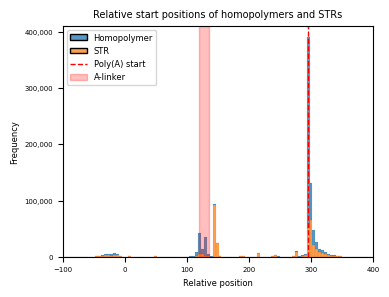

In [13]:
# plot the histogram of consensus relative start
fig = plt.figure(figsize=(4,3))
str_labels = combined_div["STR"].map({
    True: "STR",
    False: "Homopolymer",
})

ax = sb.histplot(
    data=combined_div,
    x="consensus_relative_start",
    hue=str_labels,
    hue_order=["Homopolymer", "STR"],
    multiple="stack",
    bins=500
)

plt.axvline(x=296, color='red', linestyle='--',label='Poly(A) start', linewidth=1)
plt.axvspan(120, 136, color='red', alpha=0.25, label='A-linker', linewidth=1)
plt.title("Relative start positions of homopolymers and STRs", fontsize=title_size)
plt.xlabel("Relative position", fontsize=label_size)
plt.ylabel("Frequency", fontsize=label_size)
plt.xlim(-100, 400)
# add commas to the y-axis
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "{:,}".format(int(x))))
plt.xticks(fontsize=ticks_sizes)
plt.yticks(fontsize=ticks_sizes)

# combine the histplot's legend (stored on ax.legend_) with the axvline/axvspan legend handles
hist_legend = ax.legend_
hist_handles = hist_legend.legend_handles if hist_legend is not None else []
hist_labels = [t.get_text() for t in hist_legend.get_texts()] if hist_legend is not None else []
line_handles, line_labels = ax.get_legend_handles_labels()

all_handles = hist_handles + line_handles
all_labels = hist_labels + line_labels
ax.legend(all_handles, all_labels, fontsize=label_size)

ranges = {
    "A-linker (115–137)": (115, 137),
    "poly(A) (296–336)": (290, 336),
}

for name, (start, end) in ranges.items():
    in_range = combined_div["consensus_relative_start"].between(start, end)
    n_homopolymers = in_range.sum()
    n_strs = (in_range & combined_div["STR"].eq(True)).sum()

    print(f"{name}:")
    print(f"  Homopolymers: {n_homopolymers:,}")
    print(f"  STRs: {n_strs:,}")
# save the histogram as a supplemental figure
plt.savefig(f"{plot_dir_5}/homopolymers_vs_STRs_histogram.pdf", dpi=300, bbox_inches='tight')

# Figure 5

## Figure 5B: Alu-STR frequency by divergence

In [14]:
combined_div["Alu_subfamily"] = combined_div["Alu_subfamily"].fillna(combined_div["mei_subfamily"].map(lambda x: "AluY" if "AluY" in x else ("AluS" if "AluS" in x else ("AluJ" if "AluJ" in x else None))))
combined_div.Alu_subfamily.value_counts()

Alu_subfamily
AluS    634459
AluJ    202031
AluY    141546
Name: count, dtype: int64

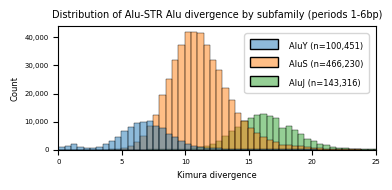

In [15]:
# plot the distribution of divergence by Alu family in our data
fig, ax = plt.subplots(figsize=(4, 2))

plot_data = combined_div.drop_duplicates(
    subset=["chrom", "start_mei", "end_mei"]
)

counts = plot_data["Alu_subfamily"].value_counts()
hue_order = ["AluY", "AluS", "AluJ"]
hue_labels = [f"{subfamily} (n={counts.get(subfamily, 0):,})" for subfamily in hue_order]

plot_data = plot_data.copy()
plot_data["Alu_subfamily_label"] = plot_data["Alu_subfamily"].map(
    dict(zip(hue_order, hue_labels))
)

sb.histplot(
    data=plot_data,
    x="divergence",
    hue="Alu_subfamily_label",
    hue_order=hue_labels,
    ax=ax,
    legend=True,
    binwidth=0.5,
)

plt.title(
    "Distribution of Alu-STR Alu divergence by subfamily (periods 1-6bp)",
    fontsize=title_size,
)
plt.xlabel("Kimura divergence", fontsize=label_size)
plt.ylabel("Count", fontsize=label_size)
plt.xlim(0, 25)

ax.tick_params(axis="both", labelsize=ticks_sizes)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

if ax.legend_ is not None:
    ax.legend_.set_title(None)
    for text in ax.legend_.get_texts():
        text.set_fontsize(label_size)
plt.tight_layout()
plt.savefig(f"{plot_dir_5}/figure5B_alu_divergence_by_subfamily.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 5C: MEI vs non-MEI polymorphism rates

mei
False    17.371182
True     18.722803
Name: variable, dtype: float64
Fisher's exact test OR: 1.0957
Fisher's exact test p-value: 6.557e-162
Chi-square test statistic: 11760.0714, p-value: 0.000e+00
Alu vs non-TE Fisher's exact p-value: 0.000e+00
SVA vs non-TE Fisher's exact p-value: 2.409e-236
LINE1 vs non-TE Fisher's exact p-value: 3.179e-14
LINE2 vs non-TE Fisher's exact p-value: 8.449e-226


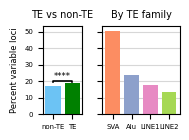

In [16]:
from scipy.stats import fisher_exact, chi2_contingency

# (1) get the percentage of regions in LPS that are variable (Stdev > 0) by mei vs non-mei
non_mei_color = "#6cc3f4"
mei_color = "green"

LPS["variable"] = LPS["Stdev"] > 0

# proportions (%)
variable_percentage = LPS.groupby("mei")["variable"].mean().reindex([False, True]) * 100
print(variable_percentage)

# Fisher's exact test on counts
contingency = pd.crosstab(LPS["mei"], LPS["variable"]).reindex(index=[False, True], columns=[False, True], fill_value=0)
odds_ratio, p_value = fisher_exact(contingency.values)

print(f"Fisher's exact test OR: {odds_ratio:.4f}")
print(f"Fisher's exact test p-value: {p_value:.3e}")

def get_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stars = get_stars(p_value)

# (2) build plot_label from mei_family
mei_family_map = {
    "SINE_Alu": "Alu",
    "Retroposon_SVA": "SVA",
    "LINE_L1": "LINE1",
    "LINE_L2": "LINE2",
    "non_mei": "non-TE",
}
LPS["plot_label"] = LPS["mei_family"].map(mei_family_map)

group_order = ["non-TE", "Alu", "SVA", "LINE1", "LINE2"]
group_order = [g for g in group_order if g in LPS["plot_label"].dropna().unique()]

variable_percentage_group = LPS.groupby("plot_label")["variable"].mean().reindex(group_order) * 100

# overall chi-square test across all groups
contingency_group = pd.crosstab(LPS["plot_label"], LPS["variable"]).reindex(index=group_order, fill_value=0)
chi2_stat, chi2_p, dof, expected = chi2_contingency(contingency_group.values)
print(f"Chi-square test statistic: {chi2_stat:.4f}, p-value: {chi2_p:.3e}")

# pairwise fisher's exact test vs non-MEI baseline for each group
baseline_counts = contingency_group.loc["non-TE"].values
group_pvalues = {}
for g in group_order:
    if g == "non-TE":
        continue
    group_counts = contingency_group.loc[g].values
    table = np.array([baseline_counts, group_counts])
    _, p = fisher_exact(table)
    group_pvalues[g] = p
    print(f"{g} vs non-TE Fisher's exact p-value: {p:.3e}")

# plot both subplots side by side
fig, axes = plt.subplots(
    1,
    2,
    figsize=(2, 1.5),
    sharey=True,
    gridspec_kw={"width_ratios": [1, 2]}
)

# Add horizontal grid lines
for ax in axes:
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="-", alpha=0.5)

axes[0].tick_params(axis="x", labelsize=ticks_sizes)
axes[1].tick_params(axis="x", labelsize=ticks_sizes)

# Subplot 1: MEI vs non-MEI
x = np.array([0, 1])
heights = variable_percentage.values

axes[0].bar(
    x=x,
    height=heights,
    color=[non_mei_color, mei_color],
    tick_label=["non-TE", "TE"]
)
axes[0].set_ylabel("Percent variable loci", fontsize=label_size)

y_max = heights.max()
y = y_max + 0.8
h = 0.5

axes[0].plot(
    [x[0], x[0], x[1], x[1]],
    [y, y + h, y + h, y],
    lw=1.2,
    c="black"
)
axes[0].text(
    0.5,
    y + h + 0.1,
    stars,
    ha="center",
    va="bottom",
    fontsize=6
)
axes[0].set_ylim(0, y + h + 1.2)
axes[0].set_title("TE vs non-TE", fontsize=title_size)
axes[0].tick_params(axis="y", labelsize=ticks_sizes)

# Subplot 2: MEI families
group_order = [
    g for g in variable_percentage_group.index
    if g != "non-TE"
]
group_order = sorted(
    group_order,
    key=lambda g: variable_percentage_group[g],
    reverse=True
)

heights2 = variable_percentage_group.reindex(group_order).values
x2 = np.arange(len(group_order))

palette = sb.color_palette("Set2", n_colors=len(group_order) + 1)
palette = palette[1:len(group_order) + 1]

colors2 = dict(zip(group_order, palette))

axes[1].bar(
    x=x2,
    height=heights2,
    color=[colors2[g] for g in group_order],
    tick_label=group_order
)
axes[1].set_title("By TE family", fontsize=title_size)
axes[1].set_ylim(0, heights2.max() + 3)

plt.tight_layout()
# save the figure
plt.savefig(plot_dir_5+"/figure5C_polymorphism_by_mei.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Figure 5D: Alu-STR polymorphism rates by divergence

In [10]:
# Any figure using LPS metrics from samples will go forward without homopolymers
combined_div["simple_motif"] = combined_div["str_motif"].apply(SequenceAttributes.get_simple_motif)
combined_div["str_period"] = combined_div["str_motif"].str.len()
combined_div["base_composition"] = combined_div["simple_motif"].apply(get_base_composition)
combined_div_str = combined_div[combined_div.STR].copy()
# combine annotation data with sample data
combined_div_str = pd.merge(left=combined_div_str, right=LPS[["LocusID","variable","Mean","Stdev","unique_lps","most_common_motif"]], how = "left", on = "LocusID")
combined_div_str["variable"] = combined_div_str.Stdev > 0

# not all of the Alus that are included in annotation level analysis will have sample level data due to QC -- drop those here
combined_div_str = combined_div_str.dropna(subset=["Stdev"])
# get the base_composition and the simple_motif based on most_common_motif
combined_div_str["simple_motif"] = combined_div_str["most_common_motif"].apply(SequenceAttributes.get_simple_motif)
combined_div_str["str_period"] = combined_div_str["most_common_motif"].str.len()
combined_div_str["base_composition"] = combined_div_str["simple_motif"].apply(get_base_composition)
combined_div_str

,chrom,start,end,LocusID,start_mei,end_mei,mei_id,mei_subfamily,orientation,consensus_relative_start,...,full_length,exclusion_type,base_composition,Alu_subfamily,str_period,variable,Mean,Stdev,unique_lps,most_common_motif
0,chr8,735310.0,735365.0,2083543.0,735178,735310,AluSc5.chr8:735178-735310,AluSc5,+,139.0,...,NaN,NaN,AT,AluS,3,True,29.181818,4.133998,7.0,AAT
1,chr20,737623.0,737660.0,4050606.0,737494,737624,AluSq2.chr20:737494-737624,AluSq2,+,133.0,...,NaN,NaN,AT,AluS,3,True,38.892857,5.101395,7.0,AAT
2,chr9,948902.0,948945.0,2300668.0,948779,948903,AluSx1.chr9:948779-948903,AluSx1,+,133.0,...,NaN,NaN,AT,AluS,3,True,40.005076,3.458965,6.0,AAT
3,chr19,1191065.0,1191093.0,3934403.0,1190941,1191057,AluSx1.chr19:1190941-1191057,AluSx1,+,133.0,...,NaN,NaN,AT,AluS,5,False,25.000000,0.000000,1.0,AAAAT
4,chr1,1653824.0,1653863.0,2476.0,1653702,1653825,AluSx.chr1:1653702-1653825,AluSx,+,126.0,...,NaN,NaN,AC,AluS,2,True,41.673684,5.342860,14.0,AC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401147,chrX,154792476.0,154792485.0,4502478.0,154792467,154792506,AluSx3.chrX:154792467-154792506,AluSx3,+,146.0,...,NaN,NaN,AC,AluS,3,False,9.000000,0.000000,1.0,ACC
401148,chrX,154833485.0,154833494.0,4502528.0,154833343,154833607,AluJo.chrX:154833343-154833607,AluJo,+,146.0,...,NaN,NaN,AC,AluJ,3,False,9.000000,0.000000,1.0,ACC
401149,chrX,155225341.0,155225350.0,4503033.0,155225247,155225499,AluSx.chrX:155225247-155225499,AluSx,-,146.0,...,NaN,NaN,AC,AluS,3,True,8.880795,0.762769,3.0,ACC
401150,chrX,155287323.0,155287342.0,4503120.0,155287322,155287615,AluSx.chrX:155287322-155287615,AluSx,-,305.0,...,NaN,NaN,AG,AluS,4,True,16.027027,0.327685,2.0,AAAG


/tmp/ipykernel_2924077/226214925.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend().remove()
/tmp/ipykernel_2924077/226214925.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend().remove()


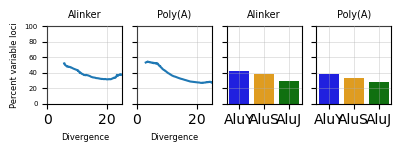

In [11]:
def create_variable_analysis_figure(combined_div_str, plot_dir=None):
    """
    Create figure with 4 subplots (Row 1 - Variable Analysis)
    """
    fig, axes = plt.subplots(1, 4, figsize=(5, 1.5), sharey='row')
    
    plt.rcParams.update({'font.size': 6,
                        'axes.titlesize': 7,
                        'axes.labelsize': 6,
                        'legend.fontsize': 5,
                        'ytick.labelsize': 5})
    color_palette = plt.cm.Paired.colors
    subfamily_palette = {"AluY": "blue", "AluS": "orange", "AluJ": "green"}
    
    var_line_handles, var_line_labels = None, None
    # change the ytick label size to 5
    for ax in axes:
        ax.tick_params(axis='y', labelsize=5)
    # Panel 1: Rolling proportion of variable in Alinker region
    plt.sca(axes[0])
    alinker_data = combined_div_str[combined_div_str.label == "Alinker"]
    data_grouped = alinker_data.groupby(["divergence", "variable"]).size()
    data_proportions = data_grouped.unstack(level=1).fillna(0)
    data_proportions = data_proportions.div(data_proportions.sum(axis=1), axis=0).rolling(window=70, min_periods=25).mean()
    data_proportions = data_proportions*100
    sorted_columns = data_proportions.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        if var == True:
            color = color_palette[i % len(color_palette)]
            sb.lineplot(data=data_proportions, x=data_proportions.index, y=var, color=color, ax=axes[0])
    
    axes[0].set_title('Alinker')
    axes[0].set_xlabel('Divergence', fontsize=6)
    axes[0].set_ylabel('Percent variable loci', fontsize=6)
    axes[0].set_xlim(0, 25)
    axes[0].set_ylim(0, 1)
    var_line_handles, var_line_labels = axes[0].get_legend_handles_labels()
    axes[0].legend().remove()
    
    # Panel 2: Rolling proportion of variable in PolyA region
    plt.sca(axes[1])
    polya_data = combined_div_str[combined_div_str.label == "Poly(A)"]
    data_grouped = polya_data.groupby(["divergence", "variable"]).size()
    data_proportions = data_grouped.unstack(level=1).fillna(0)
    data_proportions = data_proportions.div(data_proportions.sum(axis=1), axis=0).rolling(window=50, min_periods=25).mean()
    data_proportions = data_proportions*100
    
    sorted_columns = data_proportions.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        if var == True:
            color = color_palette[i % len(color_palette)]
            sb.lineplot(data=data_proportions, x=data_proportions.index, y=var, color=color, ax=axes[1])
    
    axes[1].set_title('Poly(A)')
    axes[1].set_xlabel('Divergence', fontsize=6)
    axes[1].set_ylabel('', fontsize=6)
    axes[1].set_xlim(0, 25)
    axes[1].set_ylim(0, 100)
    axes[1].legend().remove()
    
    # Panel 3: Variable distribution in Alinker region
    plt.sca(axes[2])
    alu_counts_alinker = (
        combined_div_str[combined_div_str.label == "Alinker"]
        .groupby("Alu_subfamily")["variable"]
        .value_counts(normalize=True)
        .reset_index()
    )
    alu_counts_alinker = alu_counts_alinker[alu_counts_alinker.variable == True]
    alu_counts_alinker["proportion"] = alu_counts_alinker["proportion"]*100

    sb.barplot(
        data=alu_counts_alinker,
        x="Alu_subfamily",
        y="proportion",
        order=["AluY", "AluS", "AluJ"],
        palette=subfamily_palette,
        hue="Alu_subfamily",
        legend=False,
        ax=axes[2],
    )

    axes[2].set_title("Alinker")
    axes[2].set_xlabel("", fontsize=6)
    axes[2].set_ylabel("", fontsize=6)
    axes[2].set_ylim(0, 100)

    # Panel 4: Variable distribution in PolyA region
    plt.sca(axes[3])
    alu_counts_polya = (
        combined_div_str[combined_div_str.label == "Poly(A)"]
        .groupby("Alu_subfamily")["variable"]
        .value_counts(normalize=True)
        .reset_index()
    )
    alu_counts_polya = alu_counts_polya[alu_counts_polya.variable == True]
    alu_counts_polya["proportion"] = alu_counts_polya["proportion"]*100

    sb.barplot(
        data=alu_counts_polya,
        x="Alu_subfamily",
        y="proportion",
        order=["AluY", "AluS", "AluJ"],
        palette=subfamily_palette,
        hue="Alu_subfamily",
        legend=False,
        ax=axes[3],
    )

    axes[3].set_title("Poly(A)")
    axes[3].set_xlabel("", fontsize=6)
    axes[3].set_ylabel("", fontsize=6)
    axes[3].set_ylim(0, 100)

    for ax in axes:
        ax.yaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
        ax.xaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
        for spine in ax.spines.values():
            spine.set_zorder(1)

    fig.subplots_adjust(right=0.80)
    plt.tight_layout(rect=[0, 0, 0.80, 1])
    
    if plot_dir:
        output_path = os.path.join(plot_dir, "figure5D_Alu_polymorphism.pdf")
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
        plt.show()
    
    return fig


variable_fig = create_variable_analysis_figure(combined_div_str, plot_dir=plot_dir_5)


In [12]:
# test the odds ratio and significance of the proportion variable between AluY and AluJ subfamilies for Alinker and Poly(A) labelled regions using a Fisher's exact test
for label in ["Alinker", "Poly(A)"]:
    data_label = combined_div_str[combined_div_str.label == label]
    contingency_table = pd.crosstab(data_label.Alu_subfamily, data_label.variable)
    # print the contingency table for debugging purposes
    print(f"Label: {label}, Contingency Table:\n{contingency_table.loc[['AluY', 'AluJ'], :]}\n")
    fisher_result = fisher_exact(contingency_table.loc[["AluY", "AluJ"], :])
    print(f"Label: {label}, Odds Ratio: {fisher_result[0]}, P-value: {fisher_result[1]}")

Label: Alinker, Contingency Table:
variable       False  True 
Alu_subfamily              
AluY             479    355
AluJ            6254   2657

Label: Alinker, Odds Ratio: 0.5732457424431463, P-value: 1.3033768000502273e-13
Label: Poly(A), Contingency Table:
variable       False  True 
Alu_subfamily              
AluY           11643   7426
AluJ           31034  11930

Label: Poly(A), Odds Ratio: 0.6027158887324799, P-value: 9.076082010109567e-166


In [13]:
row_normalized = contingency_table.loc[["AluY", "AluJ"], :].div(
    contingency_table.loc[["AluY", "AluJ"], :].sum(axis=1),
    axis=0
)

row_normalized

variable,False,True
Alu_subfamily,,
AluY,0.610572,0.389428
AluJ,0.722326,0.277674


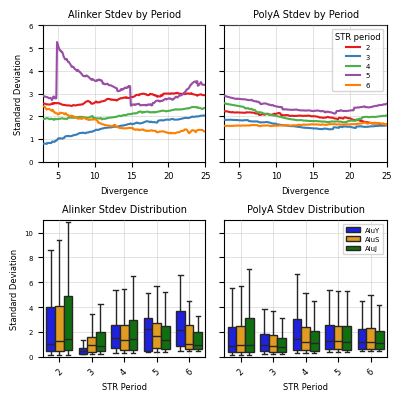

In [14]:
from matplotlib.pyplot import plot


def create_str_variability_figure(combined_div_str, plot_dir=None):
    """
    Create figure with 4 subplots in 2 rows (line plots on top, boxplots on bottom)
    Each column shares a y-axis between rows
    """
    fig, axes = plt.subplots(2, 2, figsize=(4, 4), sharey='row')
    
    plt.rcParams.update({'font.size': 6,
                        'axes.titlesize': 7,
                        'axes.labelsize': 6,
                        'legend.fontsize': 5})
    
    subfamily_palette = {"AluY": "blue", "AluS": "orange", "AluJ": "green"}
    stdev_palette = plt.cm.Set1.colors
    
    stdev_line_handles, stdev_line_labels = None, None
    
    # Panel (0,0): Standard deviation by STR period in Alinker region
    plt.sca(axes[0, 0])
    alinker_var_data = combined_div_str[(combined_div_str.label == "Alinker") & (combined_div_str.variable == True)]
    data_means_grouped = alinker_var_data.groupby(['divergence', 'str_period'])["Stdev"].mean()
    data_means = data_means_grouped.unstack(level=1)
    data_means = data_means.rolling(window=100, min_periods=10, center=True).mean()

    sorted_columns = data_means.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        if not pd.isna(var):
            color = stdev_palette[i % len(stdev_palette)]
            sb.lineplot(data=data_means, x=data_means.index, y=var, label=f'{var}', color=color, ax=axes[0, 0])
    
    axes[0, 0].set_title('Alinker Stdev by Period')
    axes[0, 0].set_xlabel('Divergence')
    axes[0, 0].set_ylabel('Standard Deviation')
    axes[0, 0].set_xlim(3, 25)
    axes[0, 0].set_ylim(0, 7)
    stdev_line_handles, stdev_line_labels = axes[0, 0].get_legend_handles_labels()

    
    # Panel (0,1): Standard deviation by STR period in PolyA region
    plt.sca(axes[0, 1])
    polya_var_data = combined_div_str[(combined_div_str.label == "Poly(A)") & (combined_div_str.variable == True)]
    data_means_grouped = polya_var_data.groupby(['divergence', 'str_period'])["Stdev"].mean()
    data_means = data_means_grouped.unstack(level=1)
    data_means = data_means.rolling(window=100, min_periods=10, center=True).mean()

    sorted_columns = data_means.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        if not pd.isna(var):
            color = stdev_palette[i % len(stdev_palette)]
            sb.lineplot(data=data_means, x=data_means.index, y=var, label=f'{var}', color=color, ax=axes[0, 1])
    
    axes[0, 1].set_title('PolyA Stdev by Period')
    axes[0, 1].set_xlabel('Divergence')
    axes[0, 1].set_ylabel('')
    axes[0, 1].set_xlim(3, 25)
    axes[0, 1].set_ylim(0, 6)
    axes[0, 0].legend().remove()
    axes[0, 1].legend(stdev_line_handles, stdev_line_labels, loc='upper right', 
                      title='STR period', fontsize=5, title_fontsize=6)
    
    # Panel (1,0): Standard deviation boxplot in Alinker region
    plt.sca(axes[1, 0])
    sb.boxplot(data=combined_div_str[(combined_div_str.label == "Alinker") & (combined_div_str.variable == True)], 
               x="str_period", y="Stdev", hue="Alu_subfamily", 
               palette=subfamily_palette, hue_order=["AluY", "AluS", "AluJ"], 
               showfliers=False, ax=axes[1, 0])
    
    axes[1, 0].set_title("Alinker Stdev Distribution")
    axes[1, 0].set_xlabel("STR Period")
    axes[1, 0].set_ylabel("Standard Deviation")
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].set_ylim(0, 11)
    
    # Panel (1,1): Standard deviation boxplot in PolyA region
    plt.sca(axes[1, 1])
    sb.boxplot(data=combined_div_str[(combined_div_str.label == "Poly(A)") & (combined_div_str.variable == True)], 
               x="str_period", y="Stdev", hue="Alu_subfamily", 
               palette=subfamily_palette, hue_order=["AluY", "AluS", "AluJ"], 
               showfliers=False, ax=axes[1, 1])
    
    axes[1, 1].set_title("PolyA Stdev Distribution")
    axes[1, 1].set_xlabel("STR Period")
    axes[1, 1].set_ylabel('')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].legend(loc='upper right', fontsize=5, title_fontsize=6)
    axes[1, 1].set_ylim(0, 11)
    axes[1, 0].legend().remove()
    
    for ax_row in axes:
        for ax in ax_row:
            ax.yaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
            ax.xaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
            for spine in ax.spines.values():
                spine.set_zorder(1)
    
    plt.tight_layout()
    
    if plot_dir:
        output_path = os.path.join(plot_dir, "supplemental_str_variance.pdf")
        plt.savefig(output_path, bbox_inches='tight', dpi=300)
        plt.show()
    
    return fig
str_variability_fig = create_str_variability_figure(combined_div_str, plot_dir=plot_dir_5)


## Figure 5E: STR period proportion by divergence

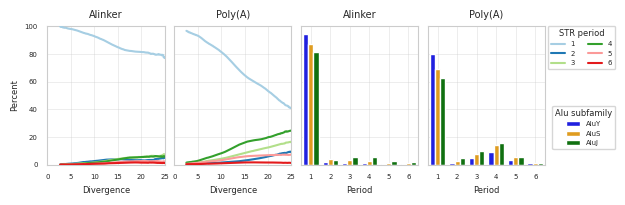

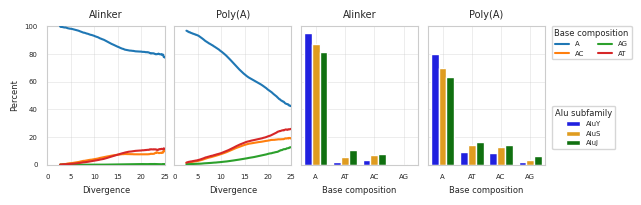

In [15]:
def create_str_and_base_composition_figures(combined_div, plot_dir=None):
    """
    Create two separate figures with 1x4 layout:
    Figure 1 - STR Period Analysis (1x4)
    Figure 2 - Base Composition Analysis (1x4)
    """
    
    # Define text sizes
    tick_size = 5
    title_size = 7
    label_size = 6
    legend_size = 5
    legend_title_size = 6
    
    # Define color palettes
    color_palette_str = plt.cm.Paired.colors
    color_palette_base = plt.cm.tab10.colors
    subfamily_palette = {"AluY": "blue", "AluS": "orange", "AluJ": "green"}
    
    plt.rcParams.update({'font.size': tick_size,
                        'axes.titlesize': title_size,
                        'axes.labelsize': label_size,
                        'legend.fontsize': legend_size,
                        'ytick.labelsize': tick_size})
    
    ###### FIGURE 1: STR PERIOD ANALYSIS ######
    fig_str, axes_str = plt.subplots(1, 4, figsize=(5.5, 2), sharey='row')
    
    for ax in axes_str:
        ax.tick_params(axis='y', labelsize=tick_size)
    
    # Panel 1: Rolling proportion of STR periods in Alinker region
    alinker_data = combined_div[combined_div.label == "Alinker"]
    data_grouped = alinker_data.groupby(["divergence", "str_period"]).size()
    data_proportions = data_grouped.unstack(level=1).fillna(0)
    data_proportions = data_proportions.div(data_proportions.sum(axis=1), axis=0).rolling(window=50, min_periods=25).mean() * 100
    
    sorted_columns = data_proportions.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        color = color_palette_str[i % len(color_palette_str)]
        sb.lineplot(data=data_proportions, x=data_proportions.index, y=var, label=f'{var}', 
                   color=color, ax=axes_str[0])
    
    axes_str[0].set_title('Alinker', fontsize=title_size)
    axes_str[0].set_xlabel('Divergence', fontsize=label_size)
    axes_str[0].set_ylabel('Percent', fontsize=label_size)
    axes_str[0].set_xlim(0, 25)
    axes_str[0].set_ylim(0, 100)
    axes_str[0].tick_params(labelsize=tick_size)
    str_line_handles, str_line_labels = axes_str[0].get_legend_handles_labels()
    axes_str[0].legend().remove()
    
    # Panel 2: Rolling proportion of STR periods in PolyA region
    polya_data = combined_div[combined_div.label == "Poly(A)"]
    data_grouped = polya_data.groupby(["divergence", "str_period"]).size()
    data_proportions = data_grouped.unstack(level=1).fillna(0)
    data_proportions = data_proportions.div(data_proportions.sum(axis=1), axis=0).rolling(window=50, min_periods=25).mean() * 100
    
    sorted_columns = data_proportions.columns.sortlevel()[0]
    for i, var in enumerate(sorted_columns):
        color = color_palette_str[i % len(color_palette_str)]
        sb.lineplot(data=data_proportions, x=data_proportions.index, y=var, label=f'{var}', 
                   color=color, ax=axes_str[1])
    
    axes_str[1].set_title('Poly(A)', fontsize=title_size)
    axes_str[1].set_xlabel('Divergence', fontsize=label_size)
    axes_str[1].set_ylabel('', fontsize=label_size)
    axes_str[1].set_xlim(0, 25)
    axes_str[1].set_ylim(0, 100)
    axes_str[1].tick_params(labelsize=tick_size)
    axes_str[1].legend().remove()
    
    # Panel 3: Discrete STR period distribution in Alinker region
    alu_counts_alinker = combined_div[combined_div.label == "Alinker"].groupby(["Alu_subfamily"]).str_period.value_counts(normalize=True).reset_index()
    alu_counts_alinker["proportion"] = alu_counts_alinker["proportion"] * 100
    sb.barplot(x=alu_counts_alinker.str_period, y=alu_counts_alinker.proportion, 
               hue=alu_counts_alinker.Alu_subfamily, palette=subfamily_palette, 
               hue_order=["AluY", "AluS", "AluJ"], ax=axes_str[2])
    
    axes_str[2].set_title("Alinker", fontsize=title_size)
    axes_str[2].set_xlabel("Period", fontsize=label_size)
    axes_str[2].set_ylabel("", fontsize=label_size)
    axes_str[2].tick_params(axis='x', labelsize=tick_size)
    axes_str[2].tick_params(axis='y', labelsize=tick_size)
    axes_str[2].set_ylim(0, 100)
    str_bar_handles, str_bar_labels = axes_str[2].get_legend_handles_labels()
    axes_str[2].legend().remove()
    
    # Panel 4: Discrete STR period distribution in PolyA region
    alu_counts_polya = combined_div[combined_div.label == "Poly(A)"].groupby(["Alu_subfamily"]).str_period.value_counts(normalize=True).reset_index()
    alu_counts_polya["proportion"] = alu_counts_polya["proportion"] * 100
    sb.barplot(x=alu_counts_polya.str_period, y=alu_counts_polya.proportion, 
               hue=alu_counts_polya.Alu_subfamily, palette=subfamily_palette, 
               hue_order=["AluY", "AluS", "AluJ"], ax=axes_str[3])
    
    axes_str[3].set_title("Poly(A)", fontsize=title_size)
    axes_str[3].set_xlabel("Period", fontsize=label_size)
    axes_str[3].set_ylabel("", fontsize=label_size)
    axes_str[3].tick_params(axis='x', labelsize=tick_size)
    axes_str[3].tick_params(axis='y', labelsize=tick_size)
    axes_str[3].set_ylim(0, 100)
    axes_str[3].legend().remove()
    
    for ax in axes_str:
        ax.yaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
        ax.xaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
        for spine in ax.spines.values():
            spine.set_zorder(1)
            
    fig_str.legend(str_line_handles, str_line_labels, loc='upper right', bbox_to_anchor=(1.12, 0.9),
                   ncol=2, title='STR period', title_fontsize=legend_title_size, fontsize=legend_size)
    fig_str.legend(str_bar_handles, str_bar_labels, loc='upper right', 
                   ncol=1, title='Alu subfamily', title_fontsize=legend_title_size,bbox_to_anchor=(1.12, 0.5), fontsize=legend_size)
    
    plt.tight_layout()
    fig_str.align_xlabels(axes_str)
    
    if plot_dir:
        output_path = os.path.join(plot_dir, "str_period_analysis_1x4.pdf")
        fig_str.savefig(output_path, bbox_inches='tight', dpi=300)
    
    ###### FIGURE 2: BASE COMPOSITION ANALYSIS ######
    # Restrict to the top 4 most abundant base compositions for this figure
    # get the top4 base compositions by overall abundance
    top4_base_compositions = combined_div["base_composition"].value_counts().nlargest(4).index.tolist()
    combined_div_base = combined_div[
        combined_div["base_composition"].isin(top4_base_compositions)
    ].copy()

    fig_base, axes_base = plt.subplots(1, 4, figsize=(5.5, 2), sharey='row')

    for ax in axes_base:
        ax.tick_params(axis='y', labelsize=tick_size)

    # Panel 1: Rolling proportion of base composition in Alinker region
    alinker_data = combined_div_base[combined_div_base.label == "Alinker"]
    data_grouped = alinker_data.groupby(["divergence", "base_composition"]).size()
    data_proportions = data_grouped.unstack(level=1).fillna(0)
    data_proportions = (
        data_proportions.div(data_proportions.sum(axis=1), axis=0)
        .rolling(window=50, min_periods=25)
        .mean() * 100
    )

    sorted_columns = data_proportions.columns.sort_values()
    for i, var in enumerate(sorted_columns):
        sb.lineplot(
            data=data_proportions,
            x=data_proportions.index,
            y=var,
            label=f"{var}",
            color=color_palette_base[i % len(color_palette_base)],
            ax=axes_base[0]
        )

    axes_base[0].set_title("Alinker", fontsize=title_size)
    axes_base[0].set_xlabel("Divergence", fontsize=label_size)
    axes_base[0].set_ylabel("Percent", fontsize=label_size)
    axes_base[0].set_xlim(0, 25)
    axes_base[0].set_ylim(0, 100)
    axes_base[0].tick_params(labelsize=tick_size)
    base_line_handles, base_line_labels = axes_base[0].get_legend_handles_labels()
    axes_base[0].legend().remove()

    # Panel 2: Rolling proportion of base composition in Poly(A) region
    polya_data = combined_div_base[combined_div_base.label == "Poly(A)"]
    data_grouped = polya_data.groupby(["divergence", "base_composition"]).size()
    data_proportions = data_grouped.unstack(level=1).fillna(0)
    data_proportions = (
        data_proportions.div(data_proportions.sum(axis=1), axis=0)
        .rolling(window=50, min_periods=25)
        .mean() * 100
    )

    sorted_columns = data_proportions.columns.sort_values()
    for i, var in enumerate(sorted_columns):
        sb.lineplot(
            data=data_proportions,
            x=data_proportions.index,
            y=var,
            label=f"{var}",
            color=color_palette_base[i % len(color_palette_base)],
            ax=axes_base[1]
        )

    axes_base[1].set_title("Poly(A)", fontsize=title_size)
    axes_base[1].set_xlabel("Divergence", fontsize=label_size)
    axes_base[1].set_ylabel("", fontsize=label_size)
    axes_base[1].set_xlim(0, 25)
    axes_base[1].set_ylim(0, 100)
    axes_base[1].tick_params(labelsize=tick_size)
    axes_base[1].legend().remove()

    # Panel 3: Base composition distribution in Alinker region
    alu_counts_alinker = (
        combined_div_base[combined_div_base.label == "Alinker"]
        .groupby("Alu_subfamily")
        .base_composition.value_counts(normalize=True)
        .reset_index(name="proportion")
    )
    alu_counts_alinker["proportion"] *= 100

    sb.barplot(
        data=alu_counts_alinker,
        x="base_composition",
        y="proportion",
        hue="Alu_subfamily",
        palette=subfamily_palette,
        hue_order=["AluY", "AluS", "AluJ"],
        ax=axes_base[2]
    )

    axes_base[2].set_title("Alinker", fontsize=title_size)
    axes_base[2].set_xlabel("Base composition", fontsize=label_size)
    axes_base[2].set_ylabel("", fontsize=label_size)
    axes_base[2].tick_params(axis="x", labelsize=tick_size)
    axes_base[2].tick_params(axis="y", labelsize=tick_size)
    axes_base[2].set_ylim(0, 100)
    base_bar_handles, base_bar_labels = axes_base[2].get_legend_handles_labels()
    axes_base[2].legend().remove()

    # Panel 4: Base composition distribution in Poly(A) region
    alu_counts_polya = (
        combined_div_base[combined_div_base.label == "Poly(A)"]
        .groupby("Alu_subfamily")
        .base_composition.value_counts(normalize=True)
        .reset_index(name="proportion")
    )
    alu_counts_polya["proportion"] *= 100

    sb.barplot(
        data=alu_counts_polya,
        x="base_composition",
        y="proportion",
        hue="Alu_subfamily",
        palette=subfamily_palette,
        hue_order=["AluY", "AluS", "AluJ"],
        ax=axes_base[3]
    )

    axes_base[3].set_title("Poly(A)", fontsize=title_size)
    axes_base[3].set_xlabel("Base composition", fontsize=label_size)
    axes_base[3].set_ylabel("", fontsize=label_size)
    axes_base[3].tick_params(axis="x", labelsize=tick_size)
    axes_base[3].tick_params(axis="y", labelsize=tick_size)
    axes_base[3].set_ylim(0, 100)
    axes_base[3].legend().remove()

    for ax in axes_base:
        ax.yaxis.grid(True, alpha=0.5, linestyle="-", linewidth=0.5, zorder=0)
        ax.xaxis.grid(True, alpha=0.5, linestyle="-", linewidth=0.5, zorder=0)
        for spine in ax.spines.values():
            spine.set_zorder(1)

    fig_base.legend(
        base_line_handles,
        base_line_labels,
        loc="upper right",
        bbox_to_anchor=(1.15, 0.9),
        ncol=2,
        title="Base composition",
        title_fontsize=legend_title_size,
        fontsize=legend_size
    )
    fig_base.legend(
        base_bar_handles,
        base_bar_labels,
        loc="upper right",
        bbox_to_anchor=(1.12, 0.5),
        ncol=1,
        title="Alu subfamily",
        title_fontsize=legend_title_size,
        fontsize=legend_size
    )

    plt.tight_layout()
    fig_base.align_xlabels(axes_base)

    if plot_dir:
        output_path = os.path.join(plot_dir, "base_composition_analysis_1x4.pdf")
        fig_base.savefig(output_path, bbox_inches="tight", dpi=300)
    
    return fig_str, fig_base

# Create the separate figures
sb.set_style("whitegrid")
fig_str, fig_base = create_str_and_base_composition_figures(combined_div, plot_dir=plot_dir_5)


In [16]:
# print what percentage of the rows are not labeled as base_compositions in the top 4 by abundance vs each of the top 4
top4_base_compositions = combined_div['base_composition'].value_counts().nlargest(4).index
total_rows = len(combined_div)
top4_count = combined_div["base_composition"].isin(top4_base_compositions).sum()

for base in top4_base_compositions:
    percentage = (
        combined_div["base_composition"].eq(base).sum()
        / total_rows
        * 100
    )
    print(f"{base}: {percentage:.2f}%")

rest_percentage = (1 - top4_count / total_rows) * 100
print(f"All other base compositions: {rest_percentage:.2f}%")

top4_base_compositions_in_alinker = combined_div[combined_div["label"] == "Alinker"]["base_composition"].value_counts().nlargest(4).index
top4_base_compositions_in_polya = combined_div[combined_div["label"] == "Poly(A)"]["base_composition"].value_counts().nlargest(4).index
print()
print("Top 4 base compositions in Alinker:")
for base in top4_base_compositions_in_alinker:
    percentage = (
        combined_div[combined_div["label"] == "Alinker"]["base_composition"].eq(base).sum()
        / combined_div["label"].eq("Alinker").sum()
        * 100
    )
    print(f"{base}: {percentage:.2f}%")

rest_percentage_in_alinker = (1 - combined_div[combined_div["label"] == "Alinker"]["base_composition"].isin(top4_base_compositions_in_alinker).sum() / combined_div["label"].eq("Alinker").sum()) * 100
print(f"All other base compositions in Alinker: {rest_percentage_in_alinker:.2f}%")
print()
print("Top 4 base compositions in Poly(A):")
for base in top4_base_compositions_in_polya:
    percentage = (
        combined_div[combined_div["label"] == "Poly(A)"]["base_composition"].eq(base).sum()
        / combined_div["label"].eq("Poly(A)").sum()
        * 100
    )
    print(f"{base}: {percentage:.2f}%")
rest_percentage_in_polya = (1 - combined_div[combined_div["label"] == "Poly(A)"]["base_composition"].isin(top4_base_compositions_in_polya).sum() / combined_div["label"].eq("Poly(A)").sum()) * 100
print(f"All other base compositions in Poly(A): {rest_percentage_in_polya:.2f}%")

A: 58.72%
AC: 22.91%
AT: 11.53%
AG: 5.29%
All other base compositions: 1.55%

Top 4 base compositions in Alinker:
A: 85.48%
AT: 7.35%
AC: 6.55%
AG: 0.26%
All other base compositions in Alinker: 0.36%

Top 4 base compositions in Poly(A):
A: 69.39%
AT: 13.58%
AC: 12.11%
AG: 3.88%
All other base compositions in Poly(A): 1.04%


In [19]:
# Print STR-period proportions for Alinker and Poly(A) regions

for region in ["Alinker", "Poly(A)"]:
    region_data = combined_div[combined_div["label"] == region]
    proportions = (
        region_data["str_period"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    print(f"\n{region} STR-period proportions:")
    for period, percentage in proportions.items():
        for subfamily in region_data["Alu_subfamily"].unique():
            subfamily_data = region_data[region_data["Alu_subfamily"] == subfamily]
            subfamily_proportion = (
                subfamily_data["str_period"]
                .value_counts(normalize=True)
                .sort_index()
                .mul(100)
                .get(period, 0)
            )
            print(f"Period {period} Subfamily {subfamily}: {subfamily_proportion:.2f}%")




Alinker STR-period proportions:
Period 1 Subfamily AluS: 87.09%
Period 1 Subfamily AluJ: 81.24%
Period 1 Subfamily AluY: 94.71%
Period 2 Subfamily AluS: 4.21%
Period 2 Subfamily AluJ: 3.07%
Period 2 Subfamily AluY: 2.29%
Period 3 Subfamily AluS: 3.37%
Period 3 Subfamily AluJ: 5.75%
Period 3 Subfamily AluY: 1.05%
Period 4 Subfamily AluS: 2.96%
Period 4 Subfamily AluJ: 5.61%
Period 4 Subfamily AluY: 0.93%
Period 5 Subfamily AluS: 1.38%
Period 5 Subfamily AluJ: 2.65%
Period 5 Subfamily AluY: 0.50%
Period 6 Subfamily AluS: 1.00%
Period 6 Subfamily AluJ: 1.68%
Period 6 Subfamily AluY: 0.52%

Poly(A) STR-period proportions:
Period 1 Subfamily AluS: 69.08%
Period 1 Subfamily AluJ: 62.49%
Period 1 Subfamily AluY: 79.98%
Period 2 Subfamily AluS: 2.68%
Period 2 Subfamily AluJ: 4.71%
Period 2 Subfamily AluY: 1.45%
Period 3 Subfamily AluS: 7.42%
Period 3 Subfamily AluJ: 9.70%
Period 3 Subfamily AluY: 4.94%
Period 4 Subfamily AluS: 14.02%
Period 4 Subfamily AluJ: 15.84%
Period 4 Subfamily AluY: 9.

In [17]:
# Statistical tests for STR period and base composition distributions
from scipy.stats import fisher_exact, kruskal
from scipy.stats.contingency import chi2_contingency
import numpy as np

print("="*80)
print("STATISTICAL TESTS FOR STR PERIOD AND BASE COMPOSITION DISTRIBUTIONS")
print("="*80)

# Function to perform Fisher's exact test for 2x2 contingency tables
def fisher_test_pairwise(data, region, feature, subfamily1, subfamily2):
    """Perform Fisher's exact test between two subfamilies for a given feature"""
    # Create contingency table for two subfamilies
    sub1_data = data[(data.label == region) & (data.Alu_subfamily == subfamily1)]
    sub2_data = data[(data.label == region) & (data.Alu_subfamily == subfamily2)]
    # Get feature value counts
    sub1_counts = sub1_data[feature].value_counts()
    sub2_counts = sub2_data[feature].value_counts()
    
    # Get all possible feature values
    all_features = sorted(set(sub1_counts.index.tolist() + sub2_counts.index.tolist()))
    
    results = {}
    
    for feat_val in all_features:
        # Create 2x2 contingency table for this feature value
        sub1_yes = sub1_counts.get(feat_val, 0)
        sub1_no = len(sub1_data) - sub1_yes
        sub2_yes = sub2_counts.get(feat_val, 0)
        sub2_no = len(sub2_data) - sub2_yes
        
        # Only perform test if we have enough data
        if sub1_yes + sub1_no > 0 and sub2_yes + sub2_no > 0:
            contingency_table = [[sub1_yes, sub1_no], [sub2_yes, sub2_no]]
            try:
                odds_ratio, p_value = fisher_exact(contingency_table)
                results[feat_val] = {
                    'odds_ratio': odds_ratio,
                    'p_value': p_value,
                    'contingency': contingency_table
                }
            except:
                results[feat_val] = {'error': 'Could not compute Fisher exact test'}
    
    return results

# Function to perform Kruskal-Wallis test for proportions across subfamilies
def kruskal_test_proportions(data, region, feature):
    """Perform Kruskal-Wallis test comparing proportions across subfamilies for each feature value"""
    
    # Get proportion data for each subfamily
    proportions_data = data[data.label == region].groupby(["Alu_subfamily"])[feature].value_counts(normalize=True).reset_index()
    
    # Get all unique feature values
    feature_values = sorted(proportions_data[feature].unique())
    
    results = {}
    
    for feat_val in feature_values:
        # Get proportions for this feature value across subfamilies
        feat_proportions = proportions_data[proportions_data[feature] == feat_val]
        
        if len(feat_proportions) >= 2:  # Need at least 2 groups
            # Create groups for Kruskal-Wallis test
            groups = []
            subfamily_names = []
            
            for subfamily in ["AluY", "AluS", "AluJ"]:
                subfamily_prop = feat_proportions[feat_proportions.Alu_subfamily == subfamily]
                if len(subfamily_prop) > 0:
                    # For Kruskal-Wallis, we need to simulate data points based on proportions
                    # We'll use the proportion value repeated 100 times to approximate
                    prop_value = subfamily_prop.proportion.iloc[0]
                    groups.append([prop_value] * 100)
                    subfamily_names.append(subfamily)
            
            if len(groups) >= 2:
                try:
                    stat, p_value = kruskal(*groups)
                    results[feat_val] = {
                        'statistic': stat,
                        'p_value': p_value,
                        'subfamilies': subfamily_names
                    }
                except:
                    results[feat_val] = {'error': 'Could not compute Kruskal-Wallis test'}
    
    return results

print("\n" + "="*60)
print("1. FISHER'S EXACT TESTS - STR PERIOD DISTRIBUTIONS")
print("="*60)

# Fisher's exact tests for STR periods
for region in ["Alinker", "PolyA"]:
    print(f"\n{region} Region - STR Period Fisher's Exact Tests:")
    print("-" * 50)
    
    # Pairwise comparisons between subfamilies
    comparisons = [("AluY", "AluS"), ("AluY", "AluJ"), ("AluS", "AluJ")]
    
    for sub1, sub2 in comparisons:
        print(f"\n{sub1} vs {sub2}:")
        fisher_results = fisher_test_pairwise(combined_div, region, "str_period", sub1, sub2)
        
        for period, result in fisher_results.items():
            if 'p_value' in result:
                significance = ""
                if result['p_value'] < 0.001:
                    significance = "***"
                elif result['p_value'] < 0.01:
                    significance = "**"
                elif result['p_value'] < 0.05:
                    significance = "*"
                
                print(f"  STR Period {period}: OR={result['odds_ratio']:.3f}, p={result['p_value']:.3e} {significance}")

print("\n" + "="*60)
print("2. KRUSKAL-WALLIS TESTS - STR PERIOD DISTRIBUTIONS")
print("="*60)

# Kruskal-Wallis tests for STR periods
for region in ["Alinker", "PolyA"]:
    print(f"\n{region} Region - STR Period Kruskal-Wallis Tests:")
    print("-" * 50)
    
    kw_results = kruskal_test_proportions(combined_div, region, "str_period")
    
    for period, result in kw_results.items():
        if 'p_value' in result:
            significance = ""
            if result['p_value'] < 0.001:
                significance = "***"
            elif result['p_value'] < 0.01:
                significance = "**"
            elif result['p_value'] < 0.05:
                significance = "*"
            
            print(f"  STR Period {period}: H-statistic={result['statistic']:.3f}, p={result['p_value']:.3e} {significance}")

print("\n" + "="*60)
print("3. FISHER'S EXACT TESTS - BASE COMPOSITION DISTRIBUTIONS")
print("="*60)

# Fisher's exact tests for base composition
for region in ["Alinker", "PolyA"]:
    print(f"\n{region} Region - Base Composition Fisher's Exact Tests:")
    print("-" * 50)
    
    # Pairwise comparisons between subfamilies
    for sub1, sub2 in comparisons:
        print(f"\n{sub1} vs {sub2}:")
        fisher_results = fisher_test_pairwise(combined_div, region, "base_composition", sub1, sub2)
        
        for base_comp, result in fisher_results.items():
            if 'p_value' in result:
                significance = ""
                if result['p_value'] < 0.001:
                    significance = "***"
                elif result['p_value'] < 0.01:
                    significance = "**"
                elif result['p_value'] < 0.05:
                    significance = "*"
                
                print(f"  Base Comp {base_comp}: OR={result['odds_ratio']:.3f}, p={result['p_value']:.3e} {significance}")

print("\n" + "="*60)
print("4. KRUSKAL-WALLIS TESTS - BASE COMPOSITION DISTRIBUTIONS")
print("="*60)

# Kruskal-Wallis tests for base composition
for region in ["Alinker", "PolyA"]:
    print(f"\n{region} Region - Base Composition Kruskal-Wallis Tests:")
    print("-" * 50)
    
    kw_results = kruskal_test_proportions(combined_div, region, "base_composition")
    
    for base_comp, result in kw_results.items():
        if 'p_value' in result:
            significance = ""
            if result['p_value'] < 0.001:
                significance = "***"
            elif result['p_value'] < 0.01:
                significance = "**"
            elif result['p_value'] < 0.05:
                significance = "*"
            
            print(f"  Base Comp {base_comp}: H-statistic={result['statistic']:.3f}, p={result['p_value']:.3e} {significance}")

print("\n" + "="*60)
print("5. SUMMARY - PROPORTION COMPARISONS")
print("="*60)

# Summary table of proportions
print("\nSTR Period Proportions by Subfamily and Region:")
print("-" * 50)
for region in ["Alinker", "PolyA"]:
    print(f"\n{region} Region:")
    prop_table = combined_div[combined_div.label == region].groupby(["Alu_subfamily"])["str_period"].value_counts(normalize=True).unstack(fill_value=0)
    print(prop_table.round(3))

print("\nBase Composition Proportions by Subfamily and Region:")
print("-" * 50)
for region in ["Alinker", "PolyA"]:
    print(f"\n{region} Region:")
    prop_table = combined_div[combined_div.label == region].groupby(["Alu_subfamily"])["base_composition"].value_counts(normalize=True).unstack(fill_value=0)
    print(prop_table.round(3))

print("\n" + "="*80)
print("Legend: *** p<0.001, ** p<0.01, * p<0.05")
print("="*80)

STATISTICAL TESTS FOR STR PERIOD AND BASE COMPOSITION DISTRIBUTIONS

1. FISHER'S EXACT TESTS - STR PERIOD DISTRIBUTIONS

Alinker Region - STR Period Fisher's Exact Tests:
--------------------------------------------------

AluY vs AluS:
  STR Period 1: OR=2.656, p=3.054e-172 ***
  STR Period 2: OR=0.533, p=3.972e-30 ***
  STR Period 3: OR=0.303, p=1.292e-62 ***
  STR Period 4: OR=0.308, p=4.079e-54 ***
  STR Period 5: OR=0.364, p=3.160e-21 ***
  STR Period 6: OR=0.515, p=5.437e-09 ***

AluY vs AluJ:
  STR Period 1: OR=4.134, p=0.000e+00 ***
  STR Period 2: OR=0.739, p=1.395e-07 ***
  STR Period 3: OR=0.173, p=1.650e-177 ***
  STR Period 4: OR=0.158, p=7.070e-183 ***
  STR Period 5: OR=0.187, p=1.477e-78 ***
  STR Period 6: OR=0.305, p=2.691e-33 ***

AluS vs AluJ:
  STR Period 1: OR=1.557, p=9.800e-121 ***
  STR Period 2: OR=1.387, p=4.717e-19 ***
  STR Period 3: OR=0.571, p=1.531e-62 ***
  STR Period 4: OR=0.513, p=6.950e-82 ***
  STR Period 5: OR=0.513, p=5.311e-40 ***
  STR Period 6:

# Figure 6

## Figure6A: Rolling mean LPS length at poly(A) tails

In [18]:
div_subset = combined_div_str[(combined_div_str.divergence >= 3) & (combined_div_str.divergence <= 20)]
polya_var_data = div_subset[(div_subset.label == "Poly(A)") &(div_subset.Mean.notna())]
alinker_var_data = div_subset[(div_subset.label == "Alinker")&(div_subset.Mean.notna())]

All Period 2: Spearman correlation with divergence = -0.21, p-value = 8.64e-03
Variable Period 2: Spearman correlation with divergence = 0.10, p-value = 2.43e-01
Non-Variable Period 2: Spearman correlation with divergence = 0.00, p-value = 9.78e-01
All Period 3: Spearman correlation with divergence = -0.83, p-value = 7.02e-39
Variable Period 3: Spearman correlation with divergence = -0.64, p-value = 7.72e-19
Non-Variable Period 3: Spearman correlation with divergence = -0.37, p-value = 3.64e-06
All Period 4: Spearman correlation with divergence = -0.89, p-value = 4.46e-54
Variable Period 4: Spearman correlation with divergence = -0.69, p-value = 1.11e-22
Non-Variable Period 4: Spearman correlation with divergence = -0.83, p-value = 2.07e-40
All Period 5: Spearman correlation with divergence = -0.72, p-value = 3.18e-25
Variable Period 5: Spearman correlation with divergence = -0.31, p-value = 1.26e-04
Non-Variable Period 5: Spearman correlation with divergence = -0.80, p-value = 1.51e-3

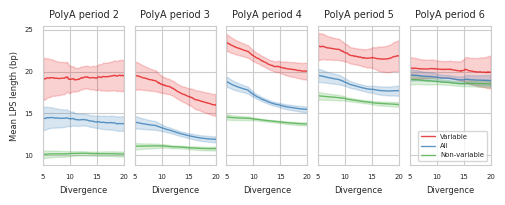

All Period 2: Spearman correlation with divergence = 0.39, p-value = 6.36e-07
Variable Period 2: Spearman correlation with divergence = 0.43, p-value = 3.85e-08
Non-Variable Period 2: Spearman correlation with divergence = 0.20, p-value = 1.42e-02
All Period 3: Spearman correlation with divergence = 0.21, p-value = 1.18e-02
Variable Period 3: Spearman correlation with divergence = 0.40, p-value = 1.08e-06
Non-Variable Period 3: Spearman correlation with divergence = -0.14, p-value = 8.76e-02
All Period 4: Spearman correlation with divergence = 0.19, p-value = 2.01e-02
Variable Period 4: Spearman correlation with divergence = 0.33, p-value = 5.53e-05
Non-Variable Period 4: Spearman correlation with divergence = -0.04, p-value = 6.35e-01
All Period 5: Spearman correlation with divergence = 0.04, p-value = 6.70e-01
Variable Period 5: Spearman correlation with divergence = 0.13, p-value = 1.39e-01
Non-Variable Period 5: Spearman correlation with divergence = -0.10, p-value = 2.35e-01
All P

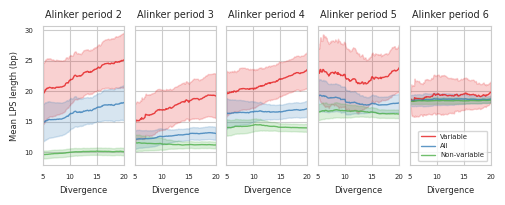

In [19]:
from regex import W
from scipy.stats import spearmanr
periods = [2, 3, 4, 5, 6]

def plot_mean_with_rolling_sem(region_data, region_name, div_min=5, div_max=20, window=30, plot_dir=None):
    data_trimmed = region_data[region_data.divergence.between(div_min, div_max)]

    # Split groups once
    pv = data_trimmed[data_trimmed.variable]
    nv = data_trimmed[~data_trimmed.variable]

    # Precompute rolling mean/sem tables
    mean_all = data_trimmed.groupby(["divergence", "str_period"])["Mean"].mean().unstack(level=1)
    sem_all = data_trimmed.groupby(["divergence", "str_period"])["Mean"].sem().unstack(level=1)

    mean_var = pv.groupby(["divergence", "str_period"])["Mean"].mean().unstack(level=1)
    sem_var = pv.groupby(["divergence", "str_period"])["Mean"].sem().unstack(level=1)

    mean_nv = nv.groupby(["divergence", "str_period"])["Mean"].mean().unstack(level=1)
    sem_nv = nv.groupby(["divergence", "str_period"])["Mean"].sem().unstack(level=1)

    # Apply rolling mean and sem
    rolling_mean_all = mean_all.rolling(window=window, min_periods=5, center=True).mean()
    rolling_sem_all = sem_all.rolling(window=window, min_periods=5, center=True).mean()

    rolling_mean_var = mean_var.rolling(window=window, min_periods=5, center=True).mean()
    rolling_sem_var = sem_var.rolling(window=window, min_periods=5, center=True).mean()

    rolling_mean_nv = mean_nv.rolling(window=window, min_periods=5, center=True).mean()
    rolling_sem_nv = sem_nv.rolling(window=window, min_periods=5, center=True).mean()

    set3_colors = plt.cm.Set1.colors
    all_color = set3_colors[1]
    var_color = set3_colors[0]
    nv_color = set3_colors[2]

    # for each mean in mean_all mean_var and mean_nv print the spearman correlation with divergence per period
    for period in periods:
        if period in mean_all.columns:
            # account for missing values
            valid = mean_all[period].notna()
            corr, pval = spearmanr(mean_all.index[valid], mean_all[period][valid])
            print(f"All Period {period}: Spearman correlation with divergence = {corr:.2f}, p-value = {pval:.2e}")
        if period in mean_var.columns:
            valid = mean_var[period].notna()
            corr, pval = spearmanr(mean_var.index[valid], mean_var[period][valid])
            print(f"Variable Period {period}: Spearman correlation with divergence = {corr:.2f}, p-value = {pval:.2e}")
        if period in mean_nv.columns:
            valid = mean_nv[period].notna()
            corr, pval = spearmanr(mean_nv.index[valid], mean_nv[period][valid])
            print(f"Non-Variable Period {period}: Spearman correlation with divergence = {corr:.2f}, p-value = {pval:.2e}")

    fig, axes = plt.subplots(1, len(periods), figsize=(5, 2), sharey=True)

    for ax, period in zip(axes, periods):
        # variable
        if period in rolling_mean_var.columns:
            x = rolling_mean_var.index
            y = rolling_mean_var[period]
            sem = rolling_sem_var[period]
            ax.plot(x, y, color=var_color, label="Variable", alpha=0.8, linewidth=1)
            ax.fill_between(x, y - sem, y + sem, color=var_color, alpha=0.2)

        # all
        if period in rolling_mean_all.columns:
            x = rolling_mean_all.index
            y = rolling_mean_all[period]
            sem = rolling_sem_all[period]
            ax.plot(x, y, color=all_color, label="All", alpha=0.8, linewidth=1)
            ax.fill_between(x, y - sem, y + sem, color=all_color, alpha=0.2)

        # non-variable
        if period in rolling_mean_nv.columns:
            x = rolling_mean_nv.index
            y = rolling_mean_nv[period]
            sem = rolling_sem_nv[period]
            ax.plot(x, y, color=nv_color, label="Non-variable", alpha=0.8, linewidth=1)
            ax.fill_between(x, y - sem, y + sem, color=nv_color, alpha=0.2)

        ax.set_title(f"{region_name} period {period}")
        ax.set_xlim(div_min, div_max)
        ax.set_xlabel("Divergence")
        ax.set_yticks(range(10, int(ax.get_ylim()[1]) + 5, 5))

    axes[0].set_ylabel("Mean LPS length (bp)")
    axes[-1].legend(loc="lower right")
    plt.tight_layout(w_pad=0.1)

    # save the plot to the plot_dir if not None
    if plot_dir is not None:
        plt.savefig(f"{plot_dir}/{region_name}_Mean_LPS_divergence_plot.pdf", bbox_inches='tight',dpi=300)
    plt.show()


# PolyA
plot_mean_with_rolling_sem(polya_var_data, "PolyA", div_min=5, div_max=20, window=80, plot_dir=plot_dir_6)

# Alinker
plot_mean_with_rolling_sem(alinker_var_data, "Alinker", div_min=5, div_max=20, window=80, plot_dir=plot_dir_6)


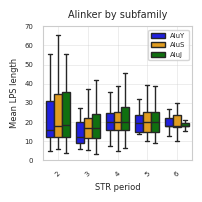

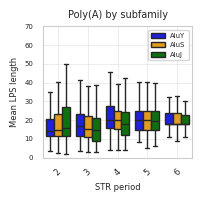

In [20]:
def create_mean_lps_boxplots_variable_figure(combined_div_str, plot_dir=None):
    """
    Create separate figures for variable regions boxplots:
    - Figure 1: Alinker region (variable regions only)
    - Figure 2: PolyA region (variable regions only)
    """
    
    # Define color palette for consistency
    subfamily_palette = {"AluY": "blue", "AluS": "orange", "AluJ": "green"}
    
    # Create Alinker Variable figure
    fig_alinker, ax_alinker = plt.subplots(1, 1, figsize=(2, 2))
    plt.rcParams.update({'font.size': 6, 'axes.titlesize': 7, 'axes.labelsize': 6, 'legend.fontsize': 5})
    
    sb.boxplot(data=combined_div_str[(combined_div_str.label == "Alinker") & (combined_div_str.variable == True)], 
               x="str_period", y="Mean", hue="Alu_subfamily", 
               palette=subfamily_palette, hue_order=["AluY", "AluS", "AluJ"], 
               showfliers=False, ax=ax_alinker)
    
    ax_alinker.set_title("Alinker by subfamily")
    ax_alinker.set_xlabel("STR period")
    ax_alinker.set_ylabel("Mean LPS length")
    ax_alinker.tick_params(axis='x', rotation=45)
    ax_alinker.set_ylim(0, 70)
    ax_alinker.yaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
    ax_alinker.xaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
    ax_alinker.legend(title="")
    plt.tight_layout()
    
    if plot_dir:
        alinker_path = os.path.join(plot_dir, "mean_lps_boxplot_alinker_variable.pdf")
        plt.savefig(alinker_path, bbox_inches='tight', dpi=300)
    plt.show()
    
    # Create PolyA Variable figure
    fig_polya, ax_polya = plt.subplots(1, 1, figsize=(2, 2))
    plt.rcParams.update({'font.size': 6, 'axes.titlesize': 7, 'axes.labelsize': 6, 'legend.fontsize': 5})
    
    sb.boxplot(data=combined_div_str[(combined_div_str.label == "Poly(A)") & (combined_div_str.variable == True)], 
               x="str_period", y="Mean", hue="Alu_subfamily", 
               palette=subfamily_palette, hue_order=["AluY", "AluS", "AluJ"], 
               showfliers=False, ax=ax_polya)
    
    ax_polya.set_title("Poly(A) by subfamily")
    ax_polya.set_xlabel("STR period")
    ax_polya.set_ylabel("Mean LPS length")
    ax_polya.tick_params(axis='x', rotation=45)
    ax_polya.set_ylim(0, 70)
    ax_polya.yaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
    ax_polya.xaxis.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, zorder=0)
    ax_polya.legend(title="")
    plt.tight_layout()
    if plot_dir:
        polya_path = os.path.join(plot_dir, "mean_lps_boxplot_polya_variable.pdf")
        plt.savefig(polya_path, bbox_inches='tight', dpi=300)
    plt.show()
    
    return fig_alinker, fig_polya

# Create the variable regions boxplots
alinker_fig, polya_fig = create_mean_lps_boxplots_variable_figure(combined_div_str, plot_dir=plot_dir_6)


## Supplemental: Unaggregated mean LPS

Poly(A), period 2, Variable: Spearman r=0.0059, p=6.050e-01
Poly(A), period 3, Variable: Spearman r=-0.1034, p=1.673e-30
Poly(A), period 4, Variable: Spearman r=-0.1086, p=2.022e-78
Poly(A), period 5, Variable: Spearman r=-0.0712, p=1.815e-13
Poly(A), period 6, Variable: Spearman r=-0.0226, p=2.169e-01
Poly(A), period 2, All: Spearman r=-0.0432, p=9.013e-09
Poly(A), period 3, All: Spearman r=-0.0748, p=6.835e-60
Poly(A), period 4, All: Spearman r=-0.1089, p=3.456e-228


/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was dep

Poly(A), period 5, All: Spearman r=-0.0909, p=2.976e-61
Poly(A), period 6, All: Spearman r=-0.0279, p=7.761e-03
Poly(A), period 2, Non-Variable: Spearman r=-0.0185, p=6.519e-02
Poly(A), period 3, Non-Variable: Spearman r=-0.0348, p=6.910e-11
Poly(A), period 4, Non-Variable: Spearman r=-0.0702, p=6.133e-64
Poly(A), period 5, Non-Variable: Spearman r=-0.0990, p=1.648e-49
Poly(A), period 6, Non-Variable: Spearman r=-0.0730, p=1.030e-08


/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was dep

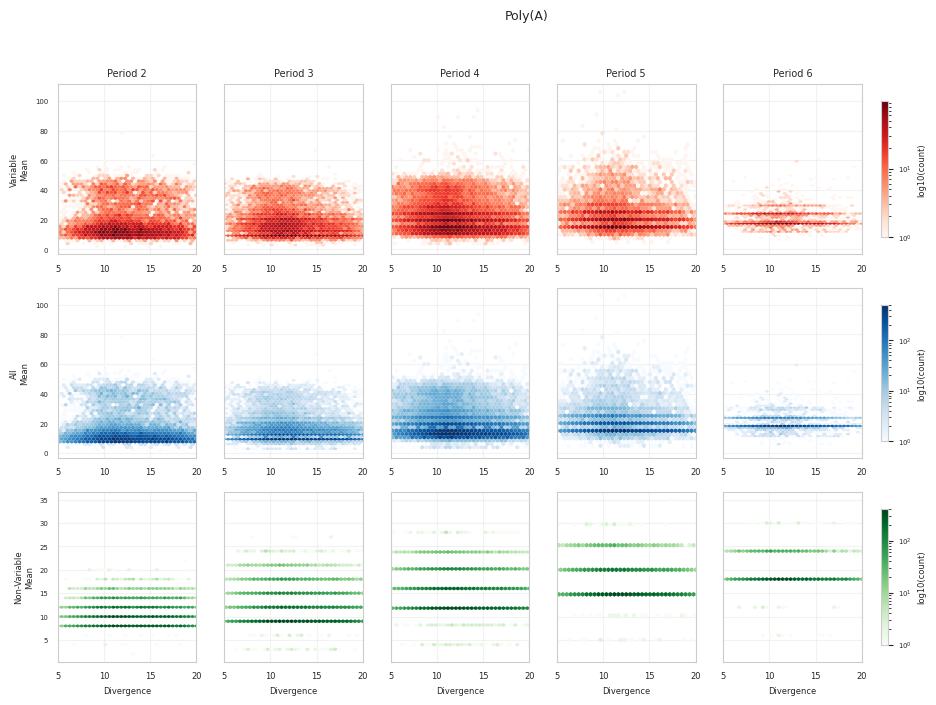

Alinker, period 2, Variable: Spearman r=0.1198, p=9.516e-07
Alinker, period 3, Variable: Spearman r=0.1018, p=1.586e-03
Alinker, period 4, Variable: Spearman r=0.1207, p=2.397e-05
Alinker, period 5, Variable: Spearman r=0.0842, p=8.121e-02
Alinker, period 6, Variable: Spearman r=0.0802, p=2.216e-01
Alinker, period 2, All: Spearman r=0.0741, p=2.693e-05
Alinker, period 3, All: Spearman r=0.0231, p=1.486e-01
Alinker, period 4, All: Spearman r=-0.0185, p=2.629e-01
Alinker, period 5, All: Spearman r=-0.0228, p=3.422e-01
Alinker, period 6, All: Spearman r=0.0224, p=4.399e-01
Alinker, period 2, Non-Variable: Spearman r=0.0677, p=7.837e-03
Alinker, period 3, Non-Variable: Spearman r=-0.0056, p=7.609e-01
Alinker, period 4, Non-Variable: Spearman r=-0.0777, p=1.225e-04
Alinker, period 5, Non-Variable: Spearman r=-0.0888, p=1.269e-03
Alinker, period 6, Non-Variable: Spearman r=-0.0110, p=7.345e-01


/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap(cmaps[name]),
/tmp/ipykernel_2027045/1566133809.py:56: MatplotlibDeprecationWarning: The get_cmap function was dep

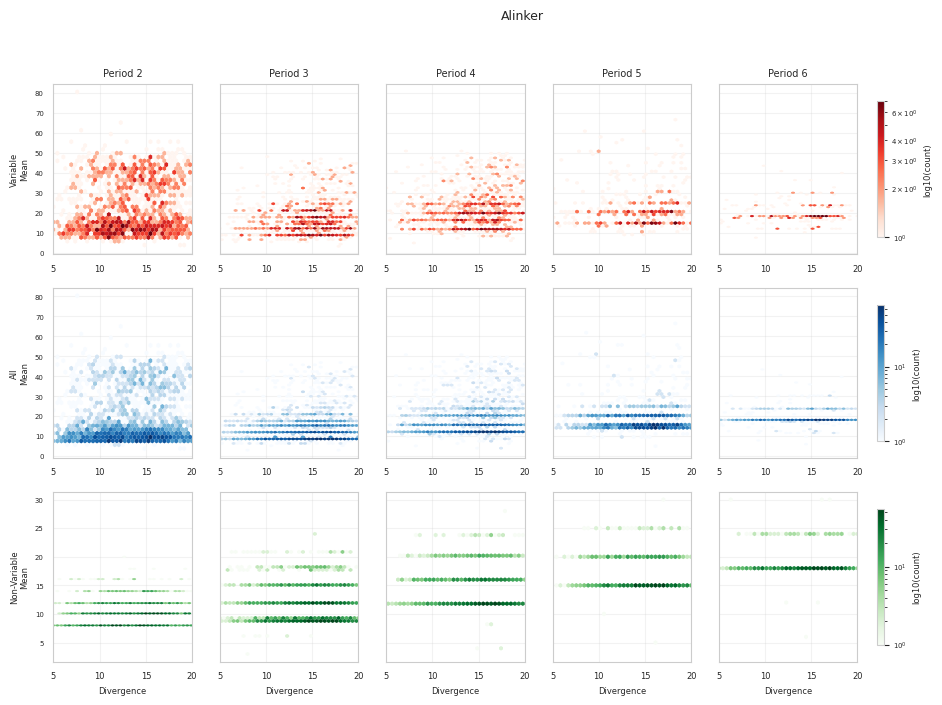

In [21]:
from scipy.stats import spearmanr
def plot_mean_density_with_spearman(
    region_data, region_name, div_min=5, div_max=20, gridsize=35, plot_dir=None
):
    data_trimmed = region_data[
        region_data["divergence"].between(div_min, div_max)
    ].copy()
    periods = [2, 3,4,5,6]
    groups = {
        "Variable": data_trimmed[data_trimmed["variable"]],
        "All": data_trimmed,
        "Non-Variable": data_trimmed[~data_trimmed["variable"]],
    }
    cmaps = {
        "Variable": "Reds",
        "All": "Blues",
        "Non-Variable": "Greens",
    }

    n_rows = len(groups)
    n_cols = len(periods)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(2.5 * n_cols, 2.5 * n_rows), sharey="row"
    )
    axes = np.atleast_2d(axes)

    for row_idx, (name, group) in enumerate(groups.items()):
        last_hb = None
        for col_idx, period in enumerate(periods):
            ax = axes[row_idx, col_idx]

            period_data = group[
                group["str_period"] == period
            ][["divergence", "Mean"]].dropna()

            if len(period_data) >= 2:
                x = period_data["divergence"].to_numpy(dtype=float)
                y = period_data["Mean"].to_numpy(dtype=float)

                valid = np.isfinite(x) & np.isfinite(y)
                x, y = x[valid], y[valid]

                if len(x) >= 2:
                    r, p_value = spearmanr(x, y)
                    print(
                        f"{region_name}, period {period}, {name}: "
                        f"Spearman r={r:.4f}, p={p_value:.3e}"
                    )

                    last_hb = ax.hexbin(
                        x,
                        y,
                        gridsize=gridsize,
                        mincnt=1,
                        bins="log",
                        cmap=plt.cm.get_cmap(cmaps[name]),
                        linewidths=0,
                    )

            if row_idx == 0:
                ax.set_title(f"Period {period}")
            if row_idx == n_rows - 1:
                ax.set_xlabel("Divergence")
            if col_idx == 0:
                ax.set_ylabel(f"{name}\nMean")

            ax.set_xlim(div_min, div_max)
            ax.grid(True, alpha=0.25)

        # add a single colorbar per row on the right
        if last_hb is not None:
            fig.colorbar(
                last_hb, ax=axes[row_idx, :].tolist(),
                label="log10(count)", shrink=0.8, pad=0.02
            )

    fig.suptitle(region_name, fontsize=title_size+2)
    # if plot_dir is specified, save the figure
    if plot_dir is not None:
        plt.savefig(f"{plot_dir}/{region_name}_mean_density.pdf", bbox_inches="tight", dpi=300)
    plt.show()


plot_mean_density_with_spearman(
    polya_var_data, "Poly(A)", div_min=5, div_max=20, plot_dir=plot_dir_6
)

plot_mean_density_with_spearman(
    alinker_var_data, "Alinker", div_min=5, div_max=20, plot_dir=plot_dir_6
)


## Figure 6E: AAAT STR LPS length over divergence by region

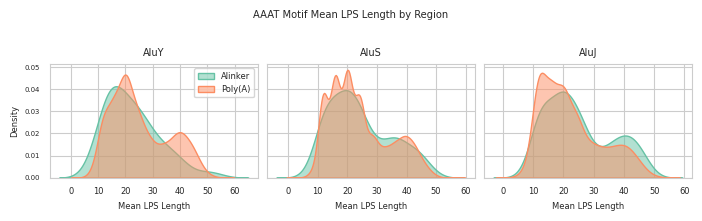

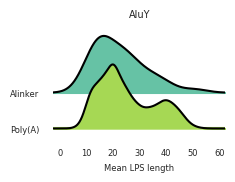

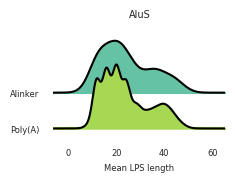

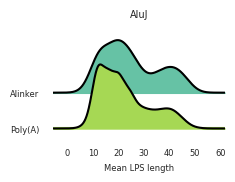

AluY Alinker - GMM Component Means: [14.50386494 27.51886461]
AluY Alinker - GMM Component Weights: [0.39298628 0.60701372]
AluY Poly(A) - GMM Component Means: [19.17293296 38.57164398]
AluY Poly(A) - GMM Component Weights: [0.69044809 0.30955191]


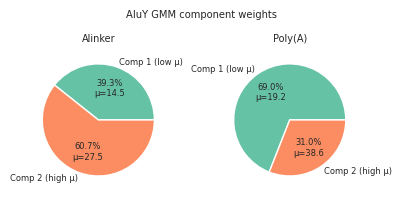

AluS Alinker - GMM Component Means: [18.53647664 37.57732163]
AluS Alinker - GMM Component Weights: [0.6978842 0.3021158]
AluS Poly(A) - GMM Component Means: [18.410232   36.71185068]
AluS Poly(A) - GMM Component Weights: [0.69612464 0.30387536]


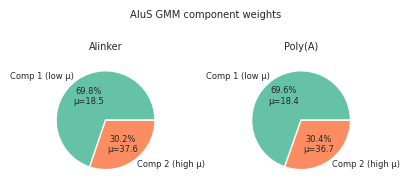

AluJ Alinker - GMM Component Means: [18.98021711 39.74128862]
AluJ Alinker - GMM Component Weights: [0.71321573 0.28678427]
AluJ Poly(A) - GMM Component Means: [17.16815442 35.91517998]
AluJ Poly(A) - GMM Component Weights: [0.7189893 0.2810107]


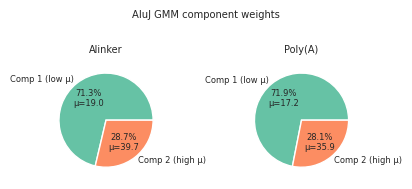


--- Pairwise comparisons of component proportions (per region) ---

Region: Alinker
  AluY vs AluS: counts AluY=[15 20], AluS=[159  67] | chi2=9.11, p=2.541e-03
  AluY vs AluJ: counts AluY=[15 20], AluJ=[333 134] | chi2=11.09, p=8.680e-04
  AluS vs AluJ: counts AluS=[159  67], AluJ=[333 134] | chi2=0.03, p=8.653e-01
  Overall (AluY vs AluS vs AluJ): chi2=12.54, p=1.889e-03

Region: Poly(A)
  AluY vs AluS: counts AluY=[1492  640], AluS=[7697 3132] | chi2=0.99, p=3.209e-01
  AluY vs AluJ: counts AluY=[1492  640], AluJ=[1551  589] | chi2=3.12, p=7.711e-02
  AluS vs AluJ: counts AluS=[7697 3132], AluJ=[1551  589] | chi2=1.64, p=2.001e-01
  Overall (AluY vs AluS vs AluJ): chi2=3.27, p=1.946e-01

--- Pairwise comparisons of component proportions (Alinker vs Poly(A), pooled across subfamilies) ---
AluY: Alinker=[15 20], Poly(A)=[1492  640] | chi2=10.71, p=1.063e-03
AluS: Alinker=[159  67], Poly(A)=[7697 3132] | chi2=0.03, p=8.702e-01
AluJ: Alinker=[333 134], Poly(A)=[1551  589] | chi2=0.21, 

In [ ]:
from scipy.stats import chi2_contingency
from sklearn.mixture import GaussianMixture
from joypy import joyplot
import os

motif = "AAAT"
subfamilies = ["AluY", "AluS", "AluJ"]

# --- Combined density plot (all three subfamilies as subplots) ---
fig, axes = plt.subplots(1, 3, figsize=(7, 2), sharey=True)
for ax, subfamily in zip(axes, subfamilies):
    sub_data = combined_div_str[
        (combined_div_str.simple_motif == motif)
        & (combined_div_str.Alu_subfamily == subfamily)
        & (combined_div_str.variable == True)
        & (combined_div_str.Mean < 60)
        & (combined_div_str.label.isin(["Alinker", "Poly(A)"]))
    ]
    for label, color in zip(["Alinker", "Poly(A)"], sb.color_palette("Set2", 2)):
        subset = sub_data[sub_data.label == label]["Mean"].dropna()
        sb.kdeplot(subset, ax=ax, fill=True, color=color, label=label, alpha=0.5)
    ax.set_title(f"{subfamily}")
    ax.set_xlabel("Mean LPS Length")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=6)
plt.suptitle(f"{motif} Motif Mean LPS Length by Region", y=1.05)
plt.tight_layout()
fig.savefig(os.path.join(plot_dir_6, "all_AAAT_density_kde_all_subfamilies.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# --- Joyplot version: Alinker on top of Poly(A), one panel per subfamily ---
for subfamily in ["AluY", "AluS", "AluJ"]:
    fig_joy, axes_joy = joyplot(
        combined_div_str[
            (combined_div_str.simple_motif == motif)
            & (combined_div_str.Alu_subfamily == subfamily)
            & (combined_div_str.variable == True)
            & (combined_div_str.Mean < 60)
            & (combined_div_str.label.isin(["Alinker", "Poly(A)"]))
        ].sort_values("label"),
        by="label",
        column=["Mean"],
        colormap=sb.color_palette("Set2", as_cmap=True), figsize=(7/3, 1.5)
    )
    plt.xlabel('Mean LPS length')
    plt.title(f"{subfamily}")
    fig_joy.savefig(os.path.join(plot_dir_6, f"AAAT_joyplot_{subfamily}.pdf"), bbox_inches="tight")
    plt.show()

# --- GMM fitting: get component means/weights and per-locus component assignments ---
gmm_results = []
assignments = {}  # (subfamily, region) -> component labels array
for subfamily in subfamilies:
    for region in ["Alinker", "Poly(A)"]:
        data_df = combined_div_str[
            (combined_div_str.simple_motif == motif)
            & (combined_div_str.Alu_subfamily == subfamily)
            & (combined_div_str.variable == True)
            & (combined_div_str.Mean < 60)
            & (combined_div_str.label == region)
        ]
        data = data_df["Mean"].dropna().values.reshape(-1, 1)

        if len(data) < 10:
            print(f"Not enough data for {subfamily} {region}")
            continue

        gmm = GaussianMixture(n_components=2, random_state=0)
        gmm.fit(data)
        means = gmm.means_.flatten()
        weights = gmm.weights_.flatten()

        # re-order components so component 0 = low mean, component 1 = high mean
        order = np.argsort(means)
        means = means[order]
        weights = weights[order]

        # get per-point component assignment, remapped to sorted order
        raw_labels = gmm.predict(data)
        remap = {old: new for new, old in enumerate(order)}
        sorted_labels = np.array([remap[l] for l in raw_labels])
        assignments[(subfamily, region)] = sorted_labels

        gmm_results.append({
            "subfamily": subfamily,
            "region": region,
            "component_means": means,
            "component_weights": weights
        })
        print(f"{subfamily} {region} - GMM Component Means: {means}")
        print(f"{subfamily} {region} - GMM Component Weights: {weights}")

    # --- Pie charts of component weights for this subfamily ---
    try:
        alinker_result = next(r for r in gmm_results if r["subfamily"] == subfamily and r["region"] == "Alinker")
        polya_result = next(r for r in gmm_results if r["subfamily"] == subfamily and r["region"] == "Poly(A)")
    except StopIteration:
        print(f"Not enough GMM results for {subfamily}")
        continue

    alinker_means = alinker_result["component_means"]
    polya_means = polya_result["component_means"]
    alinker_weights = alinker_result["component_weights"]
    polya_weights = polya_result["component_weights"]

    fig, axes = plt.subplots(1, 2, figsize=(4, 2))
    wedges0, texts0, autotexts0 = axes[0].pie(
        alinker_weights,
        labels=["Comp 1 (low μ)", "Comp 2 (high μ)"],
        autopct="%1.1f%%",
        colors=sb.color_palette("Set2", n_colors=2),
    )
    axes[0].set_title("Alinker")

    wedges1, texts1, autotexts1 = axes[1].pie(
        polya_weights,
        labels=["Comp 1 (low μ)", "Comp 2 (high μ)"],
        autopct="%1.1f%%",
        colors=sb.color_palette("Set2", n_colors=2),
    )
    axes[1].set_title("Poly(A)")

    for i, t in enumerate(autotexts0):
        t.set_text(f"{alinker_weights[i]*100:.1f}%\nμ={alinker_means[i]:.1f}")
        t.set_fontsize(6)

    for i, t in enumerate(autotexts1):
        t.set_text(f"{polya_weights[i]*100:.1f}%\nμ={polya_means[i]:.1f}")
        t.set_fontsize(6)

    plt.suptitle(f"{subfamily} GMM component weights")
    plt.tight_layout()
    fig.savefig(os.path.join(plot_dir_6, f"supplemental_pie_{subfamily}.pdf"), bbox_inches="tight", dpi=300)
    plt.show()

# --- Statistical testing: does the proportion assigned to each component differ between subfamilies? ---
def component_counts(labels):
    """Return counts of [component0, component1] from an array of 0/1 labels."""
    counts = np.bincount(labels, minlength=2)
    return counts

comparisons = [("AluY", "AluS"), ("AluY", "AluJ"), ("AluS", "AluJ")]

print("\n--- Pairwise comparisons of component proportions (per region) ---")
for region in ["Alinker", "Poly(A)"]:
    print(f"\nRegion: {region}")
    for sub1, sub2 in comparisons:
        if (sub1, region) not in assignments or (sub2, region) not in assignments:
            print(f"  {sub1} vs {sub2}: missing data")
            continue
        counts1 = component_counts(assignments[(sub1, region)])
        counts2 = component_counts(assignments[(sub2, region)])
        table = np.array([counts1, counts2])
        chi2, p, dof, expected = chi2_contingency(table)
        print(f"  {sub1} vs {sub2}: counts {sub1}={counts1}, {sub2}={counts2} | chi2={chi2:.2f}, p={p:.3e}")

    all_present = all((sub, region) in assignments for sub in subfamilies)
    if all_present:
        table_all = np.array([component_counts(assignments[(sub, region)]) for sub in subfamilies])
        chi2, p, dof, expected = chi2_contingency(table_all)
        print(f"  Overall (AluY vs AluS vs AluJ): chi2={chi2:.2f}, p={p:.3e}")
    else:
        print("  Overall: missing data for one or more subfamilies")

print("\n--- Pairwise comparisons of component proportions (Alinker vs Poly(A), pooled across subfamilies) ---")
for sub in subfamilies:
    if (sub, "Alinker") not in assignments or (sub, "Poly(A)") not in assignments:
        print(f"{sub}: missing data")
        continue
    counts_alinker = component_counts(assignments[(sub, "Alinker")])
    counts_polya = component_counts(assignments[(sub, "Poly(A)")])
    table = np.array([counts_alinker, counts_polya])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{sub}: Alinker={counts_alinker}, Poly(A)={counts_polya} | chi2={chi2:.2f}, p={p:.3e}")


/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


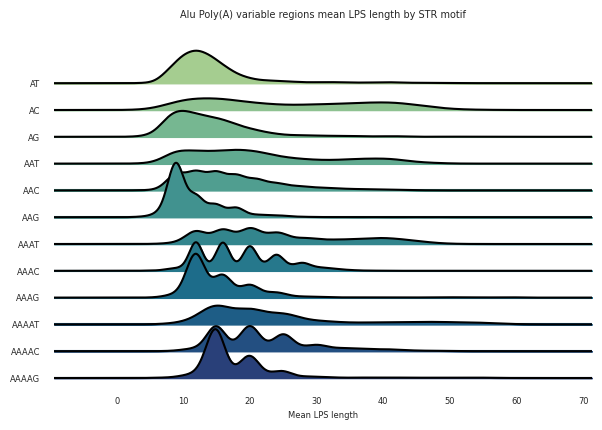

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


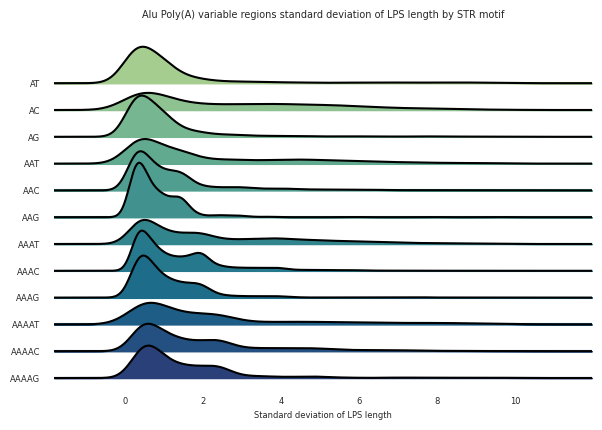

In [23]:

# sort this plot by base composition (AT, AC then AG) and then by period length (2-5)
motifs = ['AT', 'AC', 'AG', 'AAT', 'AAC', 'AAG', 'AAAT', 'AAAC', 'AAAG', 'AAAAT', 'AAAAC', 'AAAAG']
combined_div_str['motif_base'] = combined_div_str['simple_motif'].str[-1]  # Get the last base of the motif
combined_div_str = combined_div_str.sort_values(['motif_base', 'simple_motif'])

polyA_df = combined_div_str[
    (combined_div_str.Mean < 60)
    & (combined_div_str.simple_motif.isin(motifs))
    & (combined_div_str.variable == True)
    & (combined_div_str.label == "Poly(A)")
].copy()

motif_order = [
    m
    for period in sorted({len(m) for m in motifs})
    for end in ["T", "C", "G"]
    for m in motifs
    if len(m) == period and m.endswith(end)
]

polyA_df["simple_motif"] = pd.Categorical(
    polyA_df["simple_motif"],
    categories=motif_order,
    ordered=True,
)
    
joyplot(polyA_df[(polyA_df.Mean <60)&(polyA_df.simple_motif.isin(motifs))&(polyA_df.variable == True)&(polyA_df.label == "Poly(A)")].sort_values(['motif_base', 'simple_motif']), 
        by='simple_motif', column=['Mean'], colormap=sb.color_palette("crest", as_cmap=True), figsize=(6,4))
plt.xlabel('Mean LPS length')
plt.title("Alu Poly(A) variable regions mean LPS length by STR motif")
plt.show()

joyplot(
    polyA_df[polyA_df.Stdev < 10].sort_values("simple_motif"),
    by="simple_motif",
    column=["Stdev"],
    colormap=sb.color_palette("crest", as_cmap=True),
    figsize=(6,4)
)
plt.xlabel('Standard deviation of LPS length')
plt.title("Alu Poly(A) variable regions standard deviation of LPS length by STR motif")

# save to plot_dir_6
plt.savefig(f"{plot_dir_6}/polyA_mean_LPS_length_by_STR_motif.pdf", bbox_inches='tight', dpi = 300)
plt.savefig(f"{plot_dir_6}/polyA_stdev_LPS_length_by_STR_motif.pdf", bbox_inches='tight', dpi = 300)
plt.show()

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


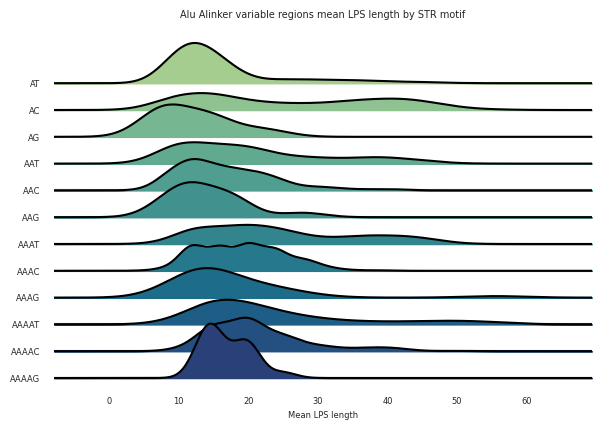

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


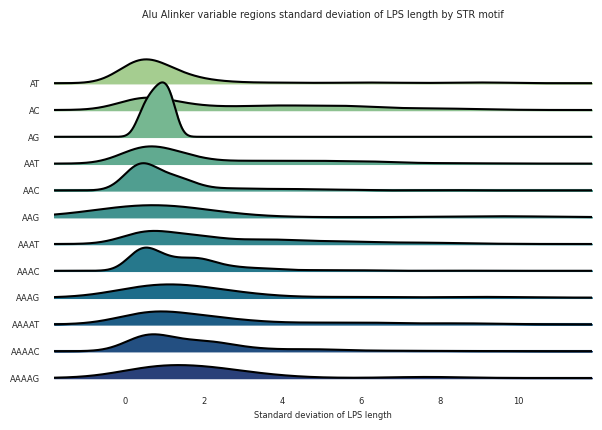

In [24]:

# sort this plot by base composition (AT, AC then AG) and then by period length (2-5)
motifs = ['AT', 'AC', 'AG', 'AAT', 'AAC', 'AAG', 'AAAT', 'AAAC', 'AAAG', 'AAAAT', 'AAAAC', 'AAAAG']
combined_div_str['motif_base'] = combined_div_str['simple_motif'].str[-1]  # Get the last base of the motif
combined_div_str = combined_div_str.sort_values(['motif_base', 'simple_motif'])

Alinker_df = combined_div_str[
    (combined_div_str.Mean < 60)
    & (combined_div_str.simple_motif.isin(motifs))
    & (combined_div_str.variable == True)
    & (combined_div_str.label == "Alinker")
].copy()

motif_order = [
    m
    for period in sorted({len(m) for m in motifs})
    for end in ["T", "C", "G"]
    for m in motifs
    if len(m) == period and m.endswith(end)
]

Alinker_df["simple_motif"] = pd.Categorical(
    Alinker_df["simple_motif"],
    categories=motif_order,
    ordered=True,
)
    
joyplot(Alinker_df[(Alinker_df.Mean <60)&(Alinker_df.simple_motif.isin(motifs))&(Alinker_df.variable == True)&(Alinker_df.label == "Alinker")].sort_values(['motif_base', 'simple_motif']), 
        by='simple_motif', column=['Mean'], colormap=sb.color_palette("crest", as_cmap=True), figsize=(6,4))
plt.xlabel('Mean LPS length')
plt.title("Alu Alinker variable regions mean LPS length by STR motif")
plt.show()

joyplot(
    Alinker_df[Alinker_df.Stdev < 10].sort_values("simple_motif"),
    by="simple_motif",
    column=["Stdev"],
    colormap=sb.color_palette("crest", as_cmap=True),
    figsize=(6,4)
)
plt.xlabel('Standard deviation of LPS length')
plt.title("Alu Alinker variable regions standard deviation of LPS length by STR motif")

# save to plot_dir_6
plt.savefig(f"{plot_dir_6}/Alinker_mean_LPS_length_by_STR_motif.pdf", bbox_inches='tight', dpi = 300)
plt.savefig(f"{plot_dir_6}/Alinker_stdev_LPS_length_by_STR_motif.pdf", bbox_inches='tight', dpi = 300)
plt.show()

# Supplement: LINE1 3' vs Alu 3' by divergence and motif

In [25]:
# get all alu and LINE1 3' and their divergence
updated_labels = pd.read_csv('final_labels_manuscript.tsv', sep='\t')
# get the LPS metreics from LPS
alus_and_line1s = updated_labels[updated_labels["mei_family"].isin(["SINE_Alu", "LINE_L1"])].copy()
alus_and_line1s = alus_and_line1s.merge(LPS[["LocusID","Mean"]], on='LocusID', how='left')
alus_and_line1s = alus_and_line1s.dropna(subset=["Mean"])
alus_and_line1s = alus_and_line1s[alus_and_line1s["divergence"].notna()]
alus_and_line1s = alus_and_line1s[alus_and_line1s.terminal_label == "3'terminal"]
alus_and_line1s

/tmp/ipykernel_2027045/2851396806.py:2: DtypeWarning: Columns (3,9,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  updated_labels = pd.read_csv('final_labels_manuscript.tsv', sep='\t')


,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,...,GencodeGeneRegion,RefseqGeneRegion,ManeGeneRegion,disease_id,genomic_annotation,keep_rel_pos,mei_family_plot,simple_motif,base_composition,Mean
3,35487,35507,46.0,39.0,35367.0,35493.0,SINE_Alu,AluJr,+,12.6,...,intron,intron,intergenic,non_disease_associated,intron,True,Alu,AAAT,AT,16.029412
4,39907,39923,53.0,44.0,39624.0,39924.0,SINE_Alu,AluSx,+,12.0,...,intergenic,intergenic,intergenic,non_disease_associated,intron,True,Alu,AAAT,AT,12.000000
10,72139,72163,103.0,80.0,72185.0,72525.0,LINE_L1,L1PA7,C,7.0,...,intergenic,intergenic,intergenic,non_disease_associated,intergenic,True,LINE1,ACAT,ACT,22.500000
23,93729,93753,129.0,111.0,93729.0,94031.0,SINE_Alu,AluSc,C,14.5,...,intron,intergenic,intergenic,non_disease_associated,intron,True,Alu,AAAAAC,AC,18.000000
24,102103,102118,144.0,125.0,101822.0,102122.0,SINE_Alu,AluSx,+,14.3,...,intron,intron,intergenic,non_disease_associated,intron,True,Alu,AAAT,AT,12.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817350,155930707,155930718,4503977.0,4657406.0,155930718.0,155936823.0,LINE_L1,L1PA5,C,5.8,...,intron,intron,intron,non_disease_associated,intron,True,LINE1,AT,AT,9.948276
817360,155983312,155983332,4504023.0,4657469.0,155983033.0,155983334.0,SINE_Alu,AluSz,+,11.6,...,intergenic,intergenic,intergenic,non_disease_associated,intergenic,True,Alu,AAAT,AT,16.000000
817361,155990197,155990213,4504031.0,4657477.0,155990198.0,155990501.0,SINE_Alu,AluSx,C,12.2,...,intergenic,intergenic,intergenic,non_disease_associated,intergenic,True,Alu,AAAC,AC,12.000000
817368,155996184,155996194,4504051.0,4657495.0,155996190.0,155996323.0,SINE_Alu,FLAM_C,C,20.1,...,intergenic,intergenic,intergenic,non_disease_associated,intergenic,True,Alu,AAT,AT,9.000000


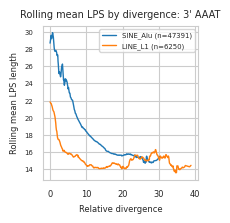

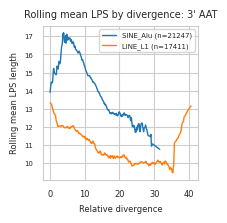

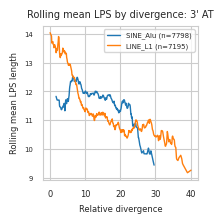

In [ ]:
# instead plot a line plot that is the rolling mean of Mean LPS by divergence for Alu vs LINE1 for the AAAT motif
def plot_rolling_mean_lps_by_divergence(
    df,
    family_col="mei_family",
    subfamily_col="mei_subfamily",
    divergence_col="mean_divergence",
    y_col="Mean",
    motif_filter_fn=None,
    window_size=3,
    figsize=(4, 3),
    title="Rolling mean LPS by divergence: 3' AAAT",
    order=["SINE_Alu", "LINE_L1"],
    save_to=None
):
    plot_df = df.copy()

    if motif_filter_fn is not None:
        plot_df = plot_df.loc[motif_filter_fn(plot_df)].copy()

    plt.figure(figsize=figsize)

    for family in order:
        fam_df = plot_df[plot_df[family_col] == family].copy()
        fam_df[divergence_col] = pd.to_numeric(fam_df[divergence_col], errors="coerce")
        fam_df[y_col] = pd.to_numeric(fam_df[y_col], errors="coerce")
        fam_df = (
            fam_df
            .dropna(subset=[divergence_col, y_col])
            .sort_values(divergence_col)
            .reset_index(drop=True)
        )
        if fam_df.empty:
            continue

        # collapse to one value per divergence, then smooth to a continuous curve
        curve_df = (
            fam_df.groupby(divergence_col, as_index=False)[y_col]
            .mean()
            .sort_values(divergence_col)
        )

        if len(curve_df) < 2:
            continue

        # rolling mean on divergence-sorted values
        min_periods = max(3, window_size // 2)
        curve_df["rolling_mean"] = (
            curve_df[y_col]
            .rolling(window=window_size, min_periods=min_periods, center=True)
            .mean()
            .interpolate(limit_direction="both")
        )

        # interpolate onto a dense x-grid for a continuous-looking line
        x_smooth = np.linspace(
            curve_df[divergence_col].min(),
            curve_df[divergence_col].max(),
            400
        )
        y_smooth = np.interp(
            x_smooth,
            curve_df[divergence_col].to_numpy(),
            curve_df["rolling_mean"].to_numpy()
        )
        # get the number of STRs for the family
        n_strs = len(fam_df)
        plt.plot(x_smooth, y_smooth, linewidth=1, label=family + f" (n={n_strs})")
    plt.xlabel("Relative divergence")
    plt.ylabel(f"Rolling mean LPS length")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if save_to is not None:
        plt.savefig(save_to, bbox_inches="tight", dpi=300)
    plt.show()

_ = plot_rolling_mean_lps_by_divergence(
    df=alus_and_line1s,
    family_col="mei_family",
    subfamily_col="mei_subfamily",
    divergence_col="divergence",
    y_col="Mean",
    motif_filter_fn=lambda d: d["simple_motif"].eq("AAAT"),
    window_size=25,
    figsize=(2, 2),
    title="Rolling mean LPS by divergence: 3' AAAT",
    save_to=plot_dir_6 + "/supplemental_L1_alu_rolling_mean_lps_aaat.pdf"
)

# plot the same for the AAT motif
_ = plot_rolling_mean_lps_by_divergence(
    df=alus_and_line1s,
    family_col="mei_family",
    subfamily_col="mei_subfamily",
    divergence_col="divergence",
    y_col="Mean",
    motif_filter_fn=lambda d: d["simple_motif"].eq("AAT"),
    window_size=25,
    figsize=(2, 2),
    title="Rolling mean LPS by divergence: 3' AAT",
    save_to=plot_dir_6 + "/supplemental_L1_alu_rolling_mean_lps_aat.pdf"
)
# plot the same for the AT motif
_ = plot_rolling_mean_lps_by_divergence(
    df=alus_and_line1s,
    family_col="mei_family",
    subfamily_col="mei_subfamily",
    divergence_col="divergence",
    y_col="Mean",
    motif_filter_fn=lambda d: d["simple_motif"].eq("AT"),
    window_size=25,
    figsize=(2, 2),
    title="Rolling mean LPS by divergence: 3' AT",
    save_to=plot_dir_6 + "/supplemental_L1_alu_rolling_mean_lps_at.pdf"
)


# Save out the Data submission tsv
Combined
1. Annotation data regardless of inclusion after sample QC (final_labels_manuscript.tsv)
1. Alu labels including consensus start and region labels (/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_strs_for_divergence_analysis.tsv)
1. LPS metrics (LPS_metrics_with_annotations.tsv.gz)
1. Outlier status, overall and poly(A)(polya_outliers_intron_all.bed and /home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript/outliers.bed)

In [38]:
# read all data files
annotations = pd.read_csv("final_labels_manuscript.tsv", sep='\t')
print(annotations.columns)

alu_labels = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_strs_for_divergence_analysis.tsv", sep='\t')
print(alu_labels.columns)

LPS = pd.read_csv("LPS_metrics_with_annotations.tsv.gz", compression='gzip', sep='\t')
print(LPS.columns)
    
polya_outliers = pd.read_csv("polya_outliers_locusids.txt", sep='\t')
print(polya_outliers.columns)

overall_outliers = pd.read_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript/outliers.bed", sep='\t', names=["chrom", "start", "end","LocusID"])
print(overall_outliers.columns)


/tmp/ipykernel_2290584/1828059215.py:2: DtypeWarning: Columns (3,9,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv("final_labels_manuscript.tsv", sep='\t')


Index(['start', 'end', 'LocusID', 'mei_id', 'start_mei', 'end_mei',
       'mei_family', 'mei_subfamily', 'orientation', 'divergence',
       'STR_classification', 'internal_external', 'original_LocusID', 'TRID',
       'str_period', 'str_motif', 'mei', 'chrom', 'terminal_label',
       'GencodeGeneRegion', 'RefseqGeneRegion', 'ManeGeneRegion', 'disease_id',
       'genomic_annotation', 'keep_rel_pos', 'mei_family_plot', 'simple_motif',
       'base_composition'],
      dtype='object')


/tmp/ipykernel_2290584/1828059215.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  alu_labels = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_strs_for_divergence_analysis.tsv", sep='\t')


Index(['chrom', 'start', 'end', 'LocusID', 'start_mei', 'end_mei', 'mei_id',
       'mei_subfamily', 'orientation', 'consensus_relative_start',
       'internal_external', 'str_motif', 'terminal_label', 'simple_motif',
       'chrom_mei', 'dist', 'start_mei_final', 'end_mei_final', 'TRID',
       'start_mei_orig', 'end_mei_orig', 'mei_subfamily_final', 'mei',
       'divergence', 'label'],
      dtype='object')
Index(['LocusID', 'chrom', 'start', 'end', 'Mean', 'Stdev', 'unique_lps',
       'disease_associated', 'exclusion_type', 'str_period', 'str_motif',
       'most_common_motif', 'disease_id', 'num_total_lps_motifs', 'mei',
       'mei_family', 'mei_subfamily', 'start_mei', 'end_mei',
       'internal_external', 'terminal_label', 'GencodeGeneRegion'],
      dtype='object')
Index(['LocusID'], dtype='object')
Index(['chrom', 'start', 'end', 'LocusID'], dtype='object')


In [39]:
# merge onto annotations and only keep non-redundant columns
# get the columns annotations does not have in common with LPS
LPS_non_redundant = LPS[
    ["LocusID"] + [
        col for col in LPS.columns
        if col not in annotations.columns and col != "LocusID"
    ]
]
print(LPS_non_redundant.columns)

# merge non-redundant LPS columns onto annotations
annotations_merged = annotations.merge(LPS_non_redundant, on="LocusID", how="left")
print(annotations_merged.columns)

# get the non-redundant alu_labels columns
alu_labels_non_redundant = alu_labels[
    ["LocusID"] + [
        col for col in alu_labels.columns
        if col != "LocusID" and col not in annotations_merged.columns
    ]
]
print(alu_labels_non_redundant.columns)

# merge non-redundant alu_labels columns onto annotations_merged
annotations_merged = annotations_merged.merge(alu_labels_non_redundant, on="LocusID", how="left")
print(annotations_merged.columns)


Index(['LocusID', 'Mean', 'Stdev', 'unique_lps', 'disease_associated',
       'exclusion_type', 'most_common_motif', 'num_total_lps_motifs'],
      dtype='object')
Index(['start', 'end', 'LocusID', 'mei_id', 'start_mei', 'end_mei',
       'mei_family', 'mei_subfamily', 'orientation', 'divergence',
       'STR_classification', 'internal_external', 'original_LocusID', 'TRID',
       'str_period', 'str_motif', 'mei', 'chrom', 'terminal_label',
       'GencodeGeneRegion', 'RefseqGeneRegion', 'ManeGeneRegion', 'disease_id',
       'genomic_annotation', 'keep_rel_pos', 'mei_family_plot', 'simple_motif',
       'base_composition', 'Mean', 'Stdev', 'unique_lps', 'disease_associated',
       'exclusion_type', 'most_common_motif', 'num_total_lps_motifs'],
      dtype='object')
Index(['LocusID', 'consensus_relative_start', 'chrom_mei', 'dist',
       'start_mei_final', 'end_mei_final', 'start_mei_orig', 'end_mei_orig',
       'mei_subfamily_final', 'label'],
      dtype='object')
Index(['start', 

In [41]:

annotations_merged["polya_outlier"] = annotations_merged["LocusID"].isin(polya_outliers["LocusID"])
print(annotations_merged["polya_outlier"].value_counts())

# get the overall_outlier column -- locusid in overall_outliers is an integer, need to convert to string with .0
# overall_outliers["LocusID"] = overall_outliers["LocusID"].astype(str) + ".0"
annotations_merged["overall_outlier"] = annotations_merged["LocusID"].isin(overall_outliers["LocusID"])
print(annotations_merged["overall_outlier"].value_counts())

polya_outlier
False    2428764
True        1254
Name: count, dtype: int64
overall_outlier
False    2420266
True        9752
Name: count, dtype: int64


In [55]:
annotations_merged.columns
# columns to drop
columns_to_drop = ["original_LocusID","internal_external","TRID","mei_family_plot","chrom_mei","start_mei_final","end_mei_final", "start_mei_orig", "end_mei_orig","mei_subfamily_final"]
# drop the columns listed in columns_to_drop
annotations_merged = annotations_merged.drop(columns=columns_to_drop)
annotations_merged

,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,...,unique_lps,disease_associated,exclusion_type,most_common_motif,num_total_lps_motifs,consensus_relative_start,dist,label,polya_outlier,overall_outlier
0,26931,26941,26.0,19.0,26791.0,27053.0,SINE_Alu,AluSp,+,9.5,...,1.0,False,keep,ACC,1.0,NaN,NaN,NaN,False,False
1,27862,27872,27.0,21.0,27833.0,28014.0,SINE_MIR,MIRb,C,33.6,...,1.0,False,keep,ATC,1.0,NaN,NaN,NaN,False,False
2,28245,28255,28.0,22.0,28151.0,28302.0,SINE_MIR,MIR,C,32.0,...,3.0,False,keep,ACT,1.0,NaN,NaN,NaN,False,False
3,30866,30892,34.0,26.0,30694.0,30848.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,9.0,False,keep,AG,1.0,NaN,NaN,NaN,False,False
4,30934,30948,36.0,26.0,30953.0,31131.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,2.0,False,keep,AG,1.0,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430013,56694117,56694136,4542235.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2430014,56694220,56694236,4542236.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2430015,56694332,56694350,4542237.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2430016,56694378,56694395,4542238.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


In [61]:
# also drop exclusion_type from annotations_merged
annotations_merged = annotations_merged.drop(columns=['exclusion_type'])
annotations_merged.columns

Index(['start', 'end', 'LocusID', 'mei_id', 'start_mei', 'end_mei',
       'mei_family', 'mei_subfamily', 'orientation', 'divergence',
       'STR_classification', 'str_period', 'str_motif', 'mei', 'chrom',
       'terminal_label', 'GencodeGeneRegion', 'RefseqGeneRegion',
       'ManeGeneRegion', 'disease_id', 'genomic_annotation', 'keep_rel_pos',
       'simple_motif', 'base_composition', 'Mean', 'Stdev', 'unique_lps',
       'disease_associated', 'most_common_motif', 'num_total_lps_motifs',
       'consensus_relative_start', 'dist', 'label', 'polya_outlier',
       'overall_outlier'],
      dtype='object')

In [ ]:
# rename the columns 'label' to 'alu_region_label' 'dist' to 'dit_to_alu' 'uniqe_lps' to 'num_unique_lps', 'genomic_annotation' to 'final_genomic_annotation'

2395733

In [63]:
annotations.TRID

0                  1-26932-26941-GTG
1                  1-27863-27872-ATC
2                  1-28246-28255-GTA
3                   1-30867-30892-CT
4                   1-30935-30948-TC
                     ...            
2430013    Y-56694118-56694136-AATGG
2430014    Y-56694221-56694236-GGAAT
2430015    Y-56694333-56694350-AATGG
2430016    Y-56694379-56694395-ATGGA
2430017    Y-56694463-56694492-AATGG
Name: TRID, Length: 2430018, dtype: object

In [64]:
import gzip
import json

import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
# read the json file
with gzip.open("/data/projects/nanopore/RepeatExpansion/coordinates/repeat_catalog_v1.hg38.1_to_1000bp_motifs.EH.with_annotations.json.gz", "rt") as f:
    gene_annotations = json.load(f)

# convert to pandas dataframe
df = pd.json_normalize(gene_annotations)
df

,LocusId,VariantType,ReferenceRegion,LocusStructure,Source,FoundInPerfectRepeatsInReference,CanonicalMotif,GencodeGeneRegion,RefseqGeneRegion,ManeGeneRegion,...,FoundInIllumina174kPolymorphicTRs,AlleleFrequenciesFromIllumina174k,StdevFromIllumina174k,VariationCluster,VariationClusterSizeDiff,ManeGeneName,ManeGeneId,ManeTranscriptId,FoundInKnownDiseaseAssociatedLoci,KnownDiseaseAssociatedLocus
0,1-10000-10108-TAACCC,Repeat,chr1:10000-10108,(TAACCC)*,PerfectRepeatsInReference,Yes,AACCCT,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1-10108-10149-AACCCT,Repeat,chr1:10108-10149,(AACCCT)*,PerfectRepeatsInReference,Yes,AACCCT,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1-10147-10179-CCCTAA,Repeat,chr1:10147-10179,(CCCTAA)*,PerfectRepeatsInReference,Yes,AACCCT,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1-10177-10233-CCTAAC,Repeat,chr1:10177-10233,(CCTAAC)*,PerfectRepeatsInReference,Yes,AACCCT,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1-10231-10249-CCCTAA,Repeat,chr1:10231-10249,(CCCTAA)*,PerfectRepeatsInReference,Yes,AACCCT,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4863036,Y-56886703-56886715-AATG,Repeat,chrY:56886703-56886715,(AATG)*,PerfectRepeatsInReference,Yes,AATG,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4863037,Y-56886790-56886799-T,Repeat,chrY:56886790-56886799,(T)*,PerfectRepeatsInReference,Yes,A,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4863038,Y-56886965-56886980-TTTC,Repeat,chrY:56886965-56886980,(TTTC)*,PerfectRepeatsInReference,Yes,AAAG,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,Y:56886943-56886980,22.0,NaN,NaN,NaN,NaN,NaN
4863039,Y-56887111-56887141-GTT,Repeat,chrY:56887111-56887141,(GTT)*,PerfectRepeatsInReference,Yes,AAC,intergenic,intergenic,intergenic,...,NaN,NaN,NaN,Y:56887101-56887165,34.0,NaN,NaN,NaN,NaN,NaN


In [65]:
# get the gene names from the dataframe and merge on TRID in annotations  'GencodeGeneName', 'GencodeGeneId', 'RefseqGeneName', 'RefseqGeneId','ManeGeneName', 'ManeGeneId'
annotations = annotations.merge(df[['LocusId','GencodeGeneName', 'GencodeGeneId', 'RefseqGeneName', 'RefseqGeneId','ManeGeneName', 'ManeGeneId']], left_on="TRID", right_on="LocusId", how="left")
# add the new columns to annotations_merged on LocusID
annotations_merged = annotations_merged.merge(annotations[['LocusID','GencodeGeneName', 'GencodeGeneId', 'RefseqGeneName', 'RefseqGeneId','ManeGeneName', 'ManeGeneId']], on="LocusID", how="left")
annotations_merged.head()

,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,...,dist,label,polya_outlier,overall_outlier,GencodeGeneName,GencodeGeneId,RefseqGeneName,RefseqGeneId,ManeGeneName,ManeGeneId
0,26931,26941,26.0,19.0,26791.0,27053.0,SINE_Alu,AluSp,+,9.5,...,NaN,NaN,False,False,NaN,NaN,WASH7P,WASH7P,NaN,NaN
1,27862,27872,27.0,21.0,27833.0,28014.0,SINE_MIR,MIRb,C,33.6,...,NaN,NaN,False,False,NaN,NaN,WASH7P,WASH7P,NaN,NaN
2,28245,28255,28.0,22.0,28151.0,28302.0,SINE_MIR,MIR,C,32.0,...,NaN,NaN,False,False,NaN,NaN,WASH7P,WASH7P,NaN,NaN
3,30866,30892,34.0,26.0,30694.0,30848.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,NaN,NaN,False,False,MIR1302-2HG,ENSG00000243485,MIR1302-2HG,MIR1302-2HG,NaN,NaN
4,30934,30948,36.0,26.0,30953.0,31131.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,NaN,NaN,False,False,MIR1302-2HG,ENSG00000243485,MIR1302-2HG,MIR1302-2HG,NaN,NaN


In [67]:
# reorder the columns to have chrom, start, end, LocusID then the rest of the columns
cols = annotations_merged.columns.tolist()
new_order = ['chrom', 'start', 'end', 'LocusID'] + [col for col in cols if col not in ['chrom', 'start', 'end', 'LocusID']]
annotations_merged = annotations_merged[new_order]
annotations_merged.head()

,chrom,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,...,dist,label,polya_outlier,overall_outlier,GencodeGeneName,GencodeGeneId,RefseqGeneName,RefseqGeneId,ManeGeneName,ManeGeneId
0,chr1,26931,26941,26.0,19.0,26791.0,27053.0,SINE_Alu,AluSp,+,...,NaN,NaN,False,False,NaN,NaN,WASH7P,WASH7P,NaN,NaN
1,chr1,27862,27872,27.0,21.0,27833.0,28014.0,SINE_MIR,MIRb,C,...,NaN,NaN,False,False,NaN,NaN,WASH7P,WASH7P,NaN,NaN
2,chr1,28245,28255,28.0,22.0,28151.0,28302.0,SINE_MIR,MIR,C,...,NaN,NaN,False,False,NaN,NaN,WASH7P,WASH7P,NaN,NaN
3,chr1,30866,30892,34.0,26.0,30694.0,30848.0,LTR_ERVL-MaLR,MLT1A,+,...,NaN,NaN,False,False,MIR1302-2HG,ENSG00000243485,MIR1302-2HG,MIR1302-2HG,NaN,NaN
4,chr1,30934,30948,36.0,26.0,30953.0,31131.0,LTR_ERVL-MaLR,MLT1A,+,...,NaN,NaN,False,False,MIR1302-2HG,ENSG00000243485,MIR1302-2HG,MIR1302-2HG,NaN,NaN


In [ ]:
# save the annotations_merged dataframe to a gzipped tsv
annotations_merged.to_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript_data.tsv.gz", sep="\t", index=False, compression="gzip")